In [1]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
import os

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, wilcoxon

In [2]:
#Load kiloword dataset
path = mne.datasets.kiloword.data_path(
    path=None,        
    force_update=False,  
    update_path=True,     
    download=True       
)

kiloword_data_folder= mne.datasets.kiloword.data_path()
print("Dataset downloaded to:", kiloword_data_folder)
# Epoched-Data
epochs_file = kiloword_data_folder / "kword_metadata-epo.fif"

# Load epoched data
epochs = mne.read_epochs(epochs_file, preload=True)
words = epochs.metadata["WORD"].tolist()
# overview
print(epochs)
epochs.info

X = epochs.get_data()          # shape: (960, 29, 256)
n, nchans, ntimes = X.shape
times = epochs.times

print(f"Trials: {n}, Channels: {nchans}, Timepoints: {ntimes}")

Dataset downloaded to: C:\Users\bolge\mne_data\MNE-kiloword-data
Reading C:\Users\bolge\mne_data\MNE-kiloword-data\kword_metadata-epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -100.00 ...     920.00 ms
        0 CTF compensation matrices available
Adding metadata with 8 columns
960 matching events found
No baseline correction applied
0 projection items activated
<EpochsFIF | 960 events (all good), -0.1 – 0.92 s (baseline off), ~54.4 MiB, data loaded, with metadata,
 'spectra': 1
 'loft': 1
 'fire': 1
 'judgment': 1
 'scuffle': 1
 'abstract': 1
 'struggle': 1
 'poetry': 1
 'attitude': 1
 'uncle': 1
 and 950 more events ...>
Trials: 960, Channels: 29, Timepoints: 256


In [3]:
np.save("times.npy", times)

In [4]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


from mne.decoding import (
    SlidingEstimator,
    GeneralizingEstimator,
    Vectorizer,
    cross_val_multiscore,
)
print(epochs.metadata.columns.tolist())

['WORD', 'Concreteness', 'WordFrequency', 'OrthographicDistance', 'NumberOfLetters', 'BigramFrequency', 'ConsonantVowelProportion', 'VisualComplexity']


In [5]:
def residualize_features(features, feature_names, cv):
    """For each feature, regress out all other features and keep the residuals (OOF)."""
    residualized_features = {}   #dict with feature name: residuals

    for i, name in enumerate(feature_names):

        # target: the feature we want to isolate
        y_target = features[:, i]

        # predictors: all other features
        X_other = np.delete(features, i, axis=1)

        # z-score target
        scaler_y = StandardScaler()
        y_scaled = scaler_y.fit_transform(y_target.reshape(-1, 1)).ravel()

        # fit Ridge model and predict out-of-fold to avoid data leakage
        model = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.1, 1, 10, 100, 1000]))
        y_pred_oof = cross_val_predict(model, X_other, y_scaled, cv=cv)

        # residuals: unique variance not explained by other features
        residualized_features[name] = y_scaled - y_pred_oof  # shape: (n,)

    return residualized_features

In [6]:

def decode_feature(X, y, cv):
    """Sliding estimator for a single scalar feature, with per-fold y scaling to avoid data leakage.
    Returns OOF predictions, per-fold Pearson r, and mean scores."""
    n, nchans, ntimes = X.shape
    fold_list = list(cv.split(X[:, :, 0]))
    n_folds = len(fold_list)
    fold_scores = np.zeros((n_folds, ntimes))
    preds = np.zeros((n, ntimes))               #OOF predictions, shape: (n, ntimes)
 
    for t in range(ntimes):
        X_t = X[:, :, t]          # slice EEG at this time point: (n, nchans)
 
        for fold_i, (train_idx, test_idx) in enumerate(fold_list):
 
            # fresh model and scaler every fold to avoid leakage
            model = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.1, 1, 10, 100, 1000]))
            y_scaler = StandardScaler()
 
            # fit y_scaler on training words only, transform training y
            y_train = y_scaler.fit_transform(y[train_idx].reshape(-1, 1)).ravel()
 
            # train model: EEG -> scaled feature
            model.fit(X_t[train_idx], y_train)
            y_pred = model.predict(X_t[test_idx])
 
            # back to original scale before storing
            preds[test_idx, t] = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()
 
            # pearson r is scale invariant: compare pred vs. actual in scaled space
            y_test_scaled = y_scaler.transform(y[test_idx].reshape(-1, 1)).ravel()
            r, _ = pearsonr(y_pred, y_test_scaled)
            fold_scores[fold_i, t] = r
 
    mean_scores = fold_scores.mean(axis=0)
    return preds, fold_scores, mean_scores
    # shapes: (n, ntimes), (n_folds, ntimes), (ntimes,)
 
 

In [7]:

def decode_vectors(X, Y, cv):
    """Sliding estimator with per-fold Y scaling to avoid data leakage.
    Returns OOF predictions, per-fold Pearson r per dim and averaged, and mean scores."""
    n, nchans, ntimes = X.shape
    ndim = Y.shape[1]    #number of embedding dimensions. Y has shape words, dimensions. so Y.shape[1] takes dimensions column
    fold_list = list(cv.split(X[:, :, 0]))
    n_folds = len(fold_list)
    preds           = np.zeros((n, ndim, ntimes))           #OOF predictions, shape: (n, ndim, ntimes)
    fold_scores     = np.zeros((n_folds, ntimes))           # mean r over dims per fold
    fold_scores_dim = np.zeros((n_folds, ndim, ntimes))     # r per dim per fold
 
    for t in range(ntimes):                       #loops over time points
        X_t = X[:, :, t]                          #epoch slice at time point t
 
        for fold_i, (train_idx, test_idx) in enumerate(fold_list):        # cv assigns each word to a train or test set for this fold
            model = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.1, 1, 10, 100, 1000]))
            y_scaler = StandardScaler()                               #every Y is scaled separately per fold.
            Y_train = y_scaler.fit_transform(Y[train_idx])
            model.fit(X_t[train_idx], Y_train)                        #train decoder on this fold
            Y_pred = model.predict(X_t[test_idx])                     #predict on held-out test fold
            preds[test_idx, :, t] = y_scaler.inverse_transform(Y_pred)    #store OOF predictions in original scale
 
            Y_test_scaled = y_scaler.transform(Y[test_idx])           #technically not necessary. pearson r is scale invariant.
 
            # pearson r per dimension
            rs = [pearsonr(Y_pred[:, d], Y_test_scaled[:, d])[0] for d in range(ndim)]
            fold_scores_dim[fold_i, :, t] = rs
            fold_scores[fold_i, t] = np.mean(rs)
 
    mean_scores = fold_scores.mean(axis=0)
    return preds, fold_scores, fold_scores_dim, mean_scores
    # shapes: (n, ndim, ntimes), (n_folds, ntimes), (n_folds, ndim, ntimes), (ntimes,)
 
 

In [8]:
import matplotlib.cm as cm

colors = cm.viridis(np.linspace(0, 1, 13)) 

def plot_scores(times, scores_dict, title, save_path=None, ylabel="Pearson r"):  
    fig, ax = plt.subplots(figsize=(12, 5))
    for (label, scores), color in zip(scores_dict.items(), colors):
        ax.plot(times, scores, label=label, color=color, linewidth=1.2)
    ax.axhline(0, color="k", linestyle="--")
    ax.axvline(0.0, color="k", linestyle="-")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

def add_sig_bars(ax, sig_windows, gap=0.01, cap_height=0.002, color="black"):
    for w in sig_windows:
        p = w["p"]
        stars = "***" if p < 0.001 else "**" if p < 0.01 else "*"
        y = w["y"]
        t0 = w["t_start"] + gap
        t1 = w["t_end"] - gap
        ax.plot([t0, t1], [y, y], color=color, linewidth=1.2, solid_capstyle="butt")
        ax.plot([t0, t0], [y - cap_height, y + cap_height], color=color, linewidth=1.2)
        ax.plot([t1, t1], [y - cap_height, y + cap_height], color=color, linewidth=1.2)
        ax.text((t0 + t1) / 2, y + cap_height + 0.00005,
        stars, ha="center", va="bottom", fontsize=10, color=color)

In [9]:
# plot settings (same for every figure)
N_LAYERS = 13
HIGHLIGHT_LAYER = 9
N_FOLDS = 10

FIGSIZE = (12, 5)
DPI = 300
TITLE_FS = 18
LABEL_FS = 14
TICK_FS = 11

OUT_DIR = "figures_out"
os.makedirs(OUT_DIR, exist_ok=True)

FEATURE_NAMES = [
    "Concreteness", "WordFrequency", "OrthographicDistance", "NumberOfLetters",
    "VisualComplexity", "BigramFrequency", "ConsonantVowelProportion",
    "Valence", "Arousal", "Dominance",
]
feature_colors = plt.cm.tab10(np.linspace(0, 1, 10))
FEATURE_COLOR = dict(zip(FEATURE_NAMES, feature_colors))
colors_gpt = plt.cm.hsv(np.linspace(0, 0.85, 13))


def mean_and_se(fold_scores):
    mean = fold_scores.mean(axis=0)
    se = fold_scores.std(axis=0) / np.sqrt(N_FOLDS)
    return mean, se


def finish_and_save(fig, ax, out_name, title, ylabel, ylim=None, legend_kwargs=None):
    # same axes, labels and font sizes -> all figures end up the same width
    ax.set_xlim(times[0], times[-1])
    ax.axhline(0, color="k", linestyle="--", linewidth=0.8)
    ax.axvline(0.0, color="k", linestyle="-", linewidth=0.8)
    ax.set_xlabel("Time (s)", fontsize=LABEL_FS)
    ax.set_ylabel(ylabel, fontsize=LABEL_FS)
    ax.set_title(title, fontsize=TITLE_FS)
    ax.tick_params(labelsize=TICK_FS)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if legend_kwargs is not None:
        ax.legend(**legend_kwargs)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, out_name), dpi=DPI, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def plot_layerwise(mean_per_layer, se_layer9, title, out_name, ylim, sig_windows=None):
    # all 13 layers, layer 9 highlighted with SE
    fig, ax = plt.subplots(figsize=FIGSIZE)
    for l in range(N_LAYERS):
        lw = 1.7 if l == HIGHLIGHT_LAYER else 1.2
        alpha = 1.0 if l == HIGHLIGHT_LAYER else 0.7
        ax.plot(times, mean_per_layer[l], color=colors_gpt[l], linewidth=lw, alpha=alpha, label=f"Layer {l}")
        if l == HIGHLIGHT_LAYER:
            ax.fill_between(times, mean_per_layer[l] - se_layer9, mean_per_layer[l] + se_layer9,
                            alpha=0.2, color=colors_gpt[HIGHLIGHT_LAYER])
    if sig_windows:
        add_sig_bars(ax, sig_windows, gap=0.0035, cap_height=0.0005, color=colors_gpt[HIGHLIGHT_LAYER])
    ylabel = "Δ Pearson r" if "Δ" in title else "Pearson r"
    finish_and_save(fig, ax, out_name, title, ylabel, ylim=ylim,
                    legend_kwargs=dict(loc="best", fontsize=9))


def plot_heatmap(delta_per_layer, title, out_name, vmin=-0.03, vmax=0.03):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    im = ax.imshow(delta_per_layer, aspect="auto", origin="upper",
                   extent=[times[0], times[-1], N_LAYERS - 0.5, -0.5],
                   cmap="RdBu_r", vmin=vmin, vmax=vmax)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("GPT2 Layer")
    ax.set_yticks(range(N_LAYERS))
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label="Δ Pearson r")
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, out_name), dpi=DPI, bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [10]:
#Load kiloword features
y_conc = epochs.metadata["Concreteness"]
y_wf   = epochs.metadata["WordFrequency"]
y_orth = epochs.metadata["OrthographicDistance"]
y_nlet = epochs.metadata["NumberOfLetters"]
y_vis  = epochs.metadata["VisualComplexity"]
y_bi   = epochs.metadata["BigramFrequency"]
y_cvp  = epochs.metadata["ConsonantVowelProportion"]

feature_names = ["Concreteness", "WordFrequency", "OrthographicDistance",
                 "NumberOfLetters", "VisualComplexity", "BigramFrequency", "ConsonantVowelProportion"]

features = np.column_stack([y_conc.values, y_wf.values, y_orth.values, y_nlet.values,
                            y_vis.values, y_bi.values, y_cvp.values])  # shape: (960, 7)

In [11]:
#Load Valence, Arousal, Dominance scales (NRC VAD Lexicon v2.1)
# download: https://saifmohammad.com/WebPages/nrc-vad.html → Unigrams/unigrams-NRC-VAD-Lexicon-v2.1.txt
nrc_vad = pd.read_csv("unigrams-NRC-VAD-Lexicon-v2.1.txt", sep="\t")


nrc_indexed = nrc_vad.set_index("term")
mask_nrc = np.array([w in nrc_indexed.index for w in words])

y_val = np.array([nrc_indexed.loc[w, "valence"]   for w in words if w in nrc_indexed.index])
y_aro = np.array([nrc_indexed.loc[w, "arousal"]   for w in words if w in nrc_indexed.index])
y_dom = np.array([nrc_indexed.loc[w, "dominance"] for w in words if w in nrc_indexed.index])

X_nrc = X[mask_nrc]
vad_names = ["Valence", "Arousal", "Dominance"]
vad_features = np.column_stack([y_val, y_aro, y_dom])  # shape: (944, 3)

print(f"Matched: {mask_nrc.sum()} of {len(words)} words")

Matched: 944 of 960 words


In [12]:
cv = KFold(n_splits=10, shuffle=True, random_state=0)

In [13]:
#Load GPT-2 Vectors

import pickle
with open('gpt2_embeddings.pkl', 'rb') as f:
    gpt2_embeddings = pickle.load(f)

n_layers = 13
ndim = 768

# align embeddings with kiloword word order
layer_vectors = {}
missing = []
for layer_idx in range(n_layers):
    vecs = []
    for w in words:
        if w.lower() in gpt2_embeddings:
            vecs.append(gpt2_embeddings[w.lower()][layer_idx, :])
        else:
            vecs.append(np.zeros(ndim))
            missing.append(w)
    layer_vectors[layer_idx] = np.array(vecs)  # shape: (960, 768)

print(f"Missing words: {len(set(missing))}")

# NRC subset
gpt_vectors = {l: layer_vectors[l][mask_nrc] for l in range(n_layers)}

Missing words: 0


In [14]:
all_features = np.column_stack([y_conc[mask_nrc].values, y_wf[mask_nrc].values, y_orth[mask_nrc].values,
                                y_nlet[mask_nrc].values, y_vis[mask_nrc].values,
                                y_bi[mask_nrc].values, y_cvp[mask_nrc].values,
                                y_val, y_aro, y_dom])
all_names = ["Concreteness", "WordFrequency", "OrthographicDistance",
             "NumberOfLetters", "VisualComplexity",
             "BigramFrequency", "ConsonantVowelProportion",
             "Valence", "Arousal", "Dominance"]

residualized_all = residualize_features(all_features, all_names, cv)

res_conc = residualized_all["Concreteness"]
res_wf   = residualized_all["WordFrequency"]
res_orth = residualized_all["OrthographicDistance"]
res_nlet = residualized_all["NumberOfLetters"]
res_vis  = residualized_all["VisualComplexity"]
res_bi   = residualized_all["BigramFrequency"]
res_cvp  = residualized_all["ConsonantVowelProportion"]
res_val  = residualized_all["Valence"]
res_aro  = residualized_all["Arousal"]
res_dom  = residualized_all["Dominance"]

In [15]:
for name, res in residualized_all.items():
    print(f"{name:30s}: mean={res.mean():.4f}, std={res.std():.4f}")

Concreteness                  : mean=-0.0005, std=0.9398
WordFrequency                 : mean=0.0009, std=0.9208
OrthographicDistance          : mean=-0.0007, std=0.5999
NumberOfLetters               : mean=-0.0000, std=0.6092
VisualComplexity              : mean=-0.0004, std=0.9909
BigramFrequency               : mean=0.0015, std=0.9192
ConsonantVowelProportion      : mean=0.0004, std=0.9717
Valence                       : mean=-0.0006, std=0.7701
Arousal                       : mean=0.0009, std=0.8140
Dominance                     : mean=-0.0001, std=0.7391


Skewness of RAW features:
-------------------------------------------------------
Concreteness               skew = -0.06   ok
WordFrequency              skew = -0.57   moderately skewed -> check Spearman
OrthographicDistance       skew = +2.25   strongly skewed -> use Spearman
NumberOfLetters            skew = -0.00   ok
VisualComplexity           skew = +0.04   ok
BigramFrequency            skew = +0.67   moderately skewed -> check Spearman
ConsonantVowelProportion   skew = +0.11   ok
Valence                    skew = -0.45   ok
Arousal                    skew = +0.51   moderately skewed -> check Spearman
Dominance                  skew = +0.19   ok

Skewness of RESIDUALIZED features:
-------------------------------------------------------
Concreteness               skew = -0.09   ok
WordFrequency              skew = -0.54   moderately skewed -> check Spearman
OrthographicDistance       skew = +6.54   strongly skewed -> use Spearman
NumberOfLetters            skew = -2.62   strongly 

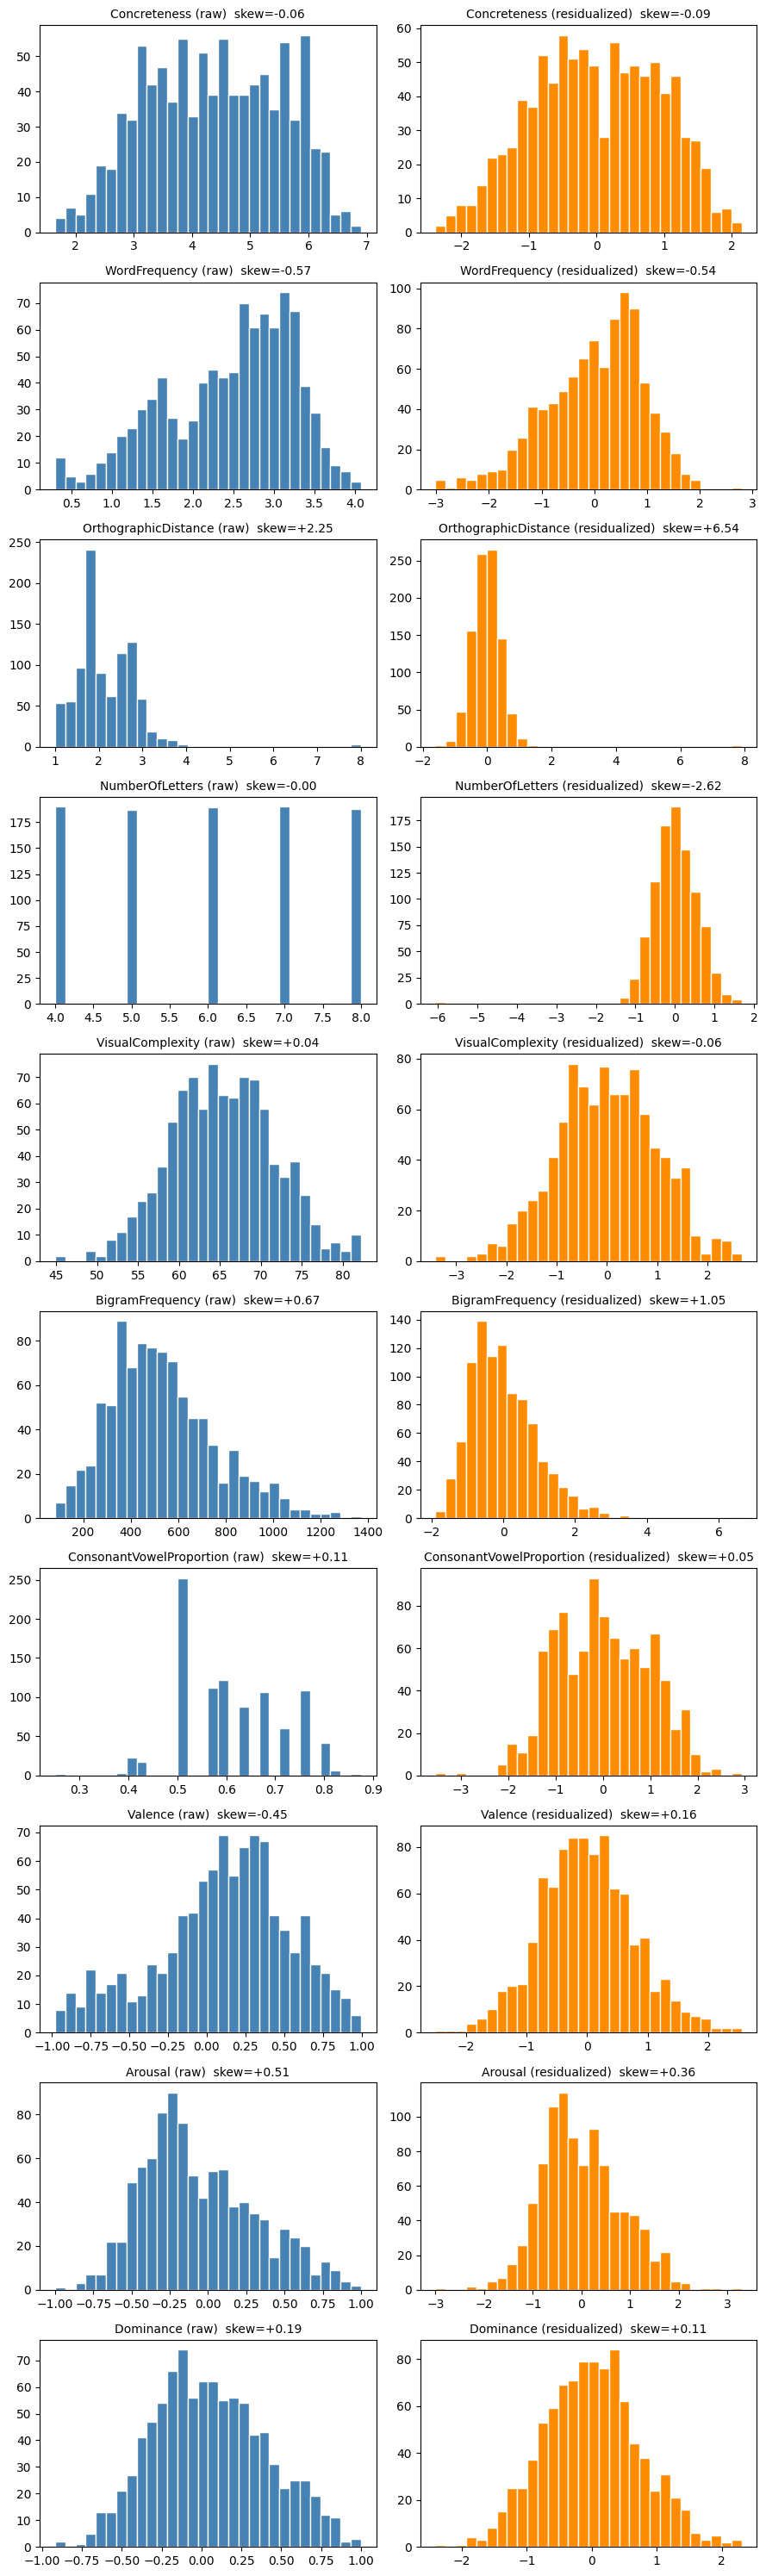

In [16]:
from scipy.stats import skew  

# 1) Skewness of the RAW features (before residualization)
print("Skewness of RAW features:")  
print("-" * 55)  
raw_skew = {}  # dict to store the skewness value for each raw feature
for i, name in enumerate(all_names):  # loop over each feature name, keeping its column index i
    s = skew(all_features[:, i])  # compute skewness of that feature's column across all words
    raw_skew[name] = s  # save the skewness value under this feature's name
    if abs(s) >= 1:  # skewness magnitude 1 or higher = strongly skewed
        flag = "strongly skewed -> use Spearman"  # recommend Spearman for this feature
    elif abs(s) >= 0.5:  # skewness magnitude between 0.5 and 1 = moderately skewed
        flag = "moderately skewed -> check Spearman"  # suggest checking Spearman as a comparison
    else:  # skewness magnitude below 0.5 = roughly symmetric
        flag = "ok"  # Pearson is fine here
    print(f"{name:26s} skew = {s:+.2f}   {flag}")  # print name, skew value, and recommendation

print()  
print("Skewness of RESIDUALIZED features:") 
print("-" * 55)  
res_skew = {}  # dict to store the skewness value for each residualized feature
for name in all_names:  # loop over each feature name
    s = skew(residualized_all[name])  # compute skewness of the residualized version of this feature
    res_skew[name] = s  # save the skewness value under this feature's name
    if abs(s) >= 1:  # same threshold logic as above
        flag = "strongly skewed -> use Spearman"  # recommend Spearman for this feature
    elif abs(s) >= 0.5:  # moderate skew threshold
        flag = "moderately skewed -> check Spearman"  # suggest checking Spearman
    else:  # roughly symmetric
        flag = "ok"  # Pearson is fine here
    print(f"{name:26s} skew = {s:+.2f}   {flag}")  # print name, skew value, and recommendation

# 2) Histograms: raw distribution vs. residualized distribution, one row per feature
fig, axes = plt.subplots(len(all_names), 2, figsize=(9, 3 * len(all_names)))  # grid with 2 columns, one row per feature
for i, name in enumerate(all_names):  # loop over each feature name, keeping its column index i
    axes[i, 0].hist(all_features[:, i], bins=30, color="steelblue", edgecolor="white")  # histogram of the raw feature (left column)
    axes[i, 0].set_title(f"{name} (raw)  skew={raw_skew[name]:+.2f}", fontsize=10)  # title showing feature name and raw skew

    axes[i, 1].hist(residualized_all[name], bins=30, color="darkorange", edgecolor="white")  # histogram of the residualized feature (right column)
    axes[i, 1].set_title(f"{name} (residualized)  skew={res_skew[name]:+.2f}", fontsize=10)  # title showing feature name and residualized skew

plt.tight_layout()  # adjust spacing so subplot titles/labels don't overlap
plt.savefig("feature_distributions_skewness.png", dpi=200, bbox_inches="tight")  # save the full figure as a PNG file
plt.show()  # display the figure
fig.savefig("feature_distributions_skewness.png", dpi=200, bbox_inches="tight")

In [20]:
#Load fasttext vectors
import io
import numpy as np

def load_selected_vectors(fname, word_list):
    """
    Loads vectors for words in word_list.

    Args:
        fname (str): path to .vec-file
        word_list (list[str]): words

    Returns:
        dict[str, np.ndarray]: words as Keys, vectors as float32-Arrays
    """
    wanted = set(word_list)      # faster search
    found = {}

    with io.open(fname, 'r', encoding='utf-8', newline='\n', errors='ignore') as fin:
        fin.readline()  #skip Header

        for line in fin:
            parts = line.rstrip().split(' ', 1)
            if len(parts) != 2:
                continue

            word, vec_str = parts

            if word in wanted:
                found[word] = np.fromstring(vec_str, sep=' ', dtype=np.float32)

                # skip early if everything was found
                if len(found) == len(wanted):
                    break

    return found

In [21]:
# FastText vectors (wiki-news-300d-1M, ~1 GB) — only needed to rerun decoding
# download: https://fasttext.cc/docs/en/english-vectors.html
FASTTEXT_PATH = "wiki-news-300d-1M.vec"
if os.path.exists(FASTTEXT_PATH):
    ftkw = load_selected_vectors(FASTTEXT_PATH, words)
    ft_vectors = np.array([ftkw[word] for word in words])  # shape: (960, 300)
    ft_vectors = ft_vectors[mask_nrc]                      # shape: (944, 300)
else:
    print("FastText file not found")

In [22]:
#overwrite X variable with subset
X = X_nrc

In [23]:
# # --- Feature Decoding ---
res_features = {
    "Concreteness":              res_conc,
    "WordFrequency":             res_wf,
    "OrthographicDistance":      res_orth,
    "NumberOfLetters":           res_nlet,
    "VisualComplexity":          res_vis,
    "BigramFrequency":           res_bi,
    "ConsonantVowelProportion":  res_cvp,
    "Valence":                   res_val,
    "Arousal":                   res_aro,
    "Dominance":                 res_dom,
}

# for name, y in res_features.items():
#     print(f"Decoding {name}...")
#     _, fold_scores, mean_scores = decode_feature(X, y, cv)
#     np.save(f"fold_scores_{name}.npy", fold_scores)
#     np.save(f"mean_scores_{name}.npy", mean_scores)
#     print(f"  done.")

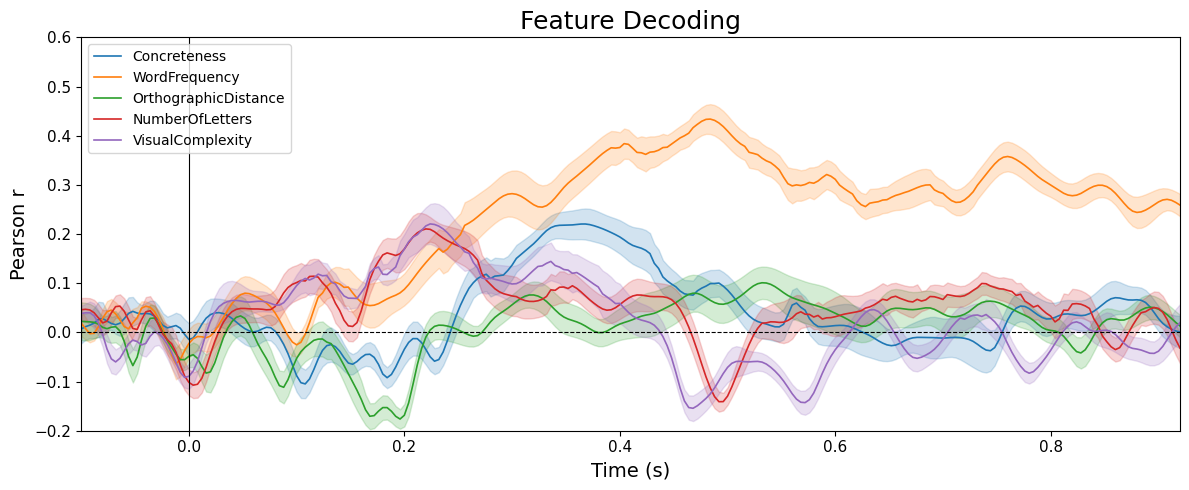

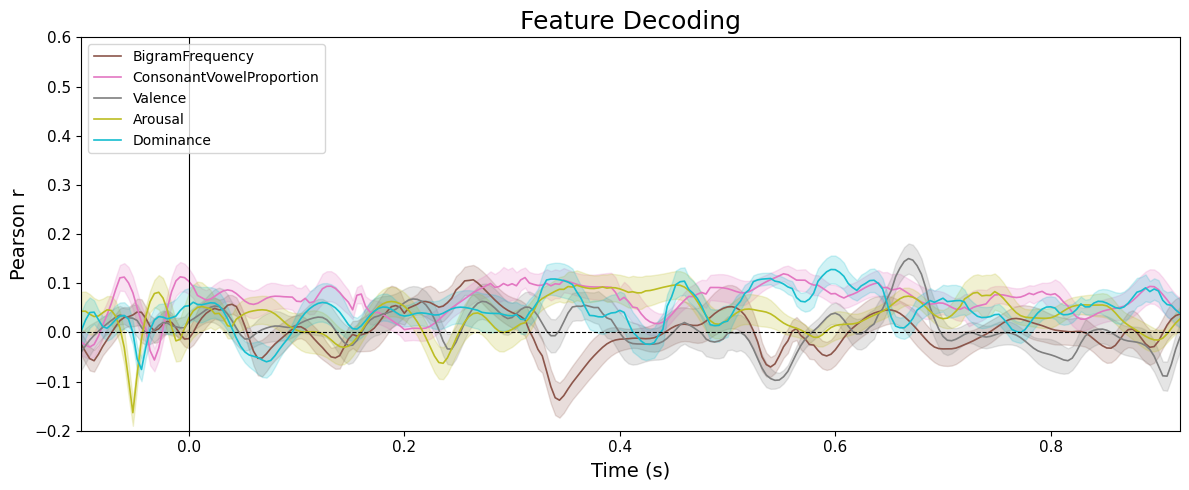

In [24]:
for i, group in enumerate([FEATURE_NAMES[:5], FEATURE_NAMES[5:]]):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    for name in group:
        fold_scores = np.load(f"fold_scores_{name}.npy")
        mean, se = mean_and_se(fold_scores)
        color = FEATURE_COLOR[name]
        ax.plot(times, mean, label=name, color=color, linewidth=1.2)
        ax.fill_between(times, mean - se, mean + se, alpha=0.2, color=color)
    finish_and_save(fig, ax, f"feature_decoding_part{i+1}.png", "Feature Decoding", "Pearson r",
                    ylim=(-0.2, 0.6), legend_kwargs=dict(loc="upper left", fontsize=10))

In [25]:
from scipy.stats import spearmanr  # add this import (alongside your existing pearsonr import)

def decode_feature_spearman(X, y, cv):
    """Sliding estimator for a single scalar feature, with per-fold y scaling to avoid data leakage.
    Returns OOF predictions, per-fold Spearman r, and mean scores."""
    n, nchans, ntimes = X.shape
    fold_list = list(cv.split(X[:, :, 0]))
    n_folds = len(fold_list)
    fold_scores = np.zeros((n_folds, ntimes))
    preds = np.zeros((n, ntimes))               #OOF predictions, shape: (n, ntimes)
 
    for t in range(ntimes):
        X_t = X[:, :, t]          # slice EEG at this time point: (n, nchans)
 
        for fold_i, (train_idx, test_idx) in enumerate(fold_list):
 
            # fresh model and scaler every fold to avoid leakage
            model = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.1, 1, 10, 100, 1000]))
            y_scaler = StandardScaler()
 
            # fit y_scaler on training words only, transform training y
            y_train = y_scaler.fit_transform(y[train_idx].reshape(-1, 1)).ravel()
 
            # train model: EEG -> scaled feature
            model.fit(X_t[train_idx], y_train)
            y_pred = model.predict(X_t[test_idx])
 
            # back to original scale before storing
            preds[test_idx, t] = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()
 
            # spearman r is rank-based and scale invariant: compare pred vs. actual in scaled space
            y_test_scaled = y_scaler.transform(y[test_idx].reshape(-1, 1)).ravel()
            r, _ = spearmanr(y_pred, y_test_scaled)
            fold_scores[fold_i, t] = r
 
    mean_scores = fold_scores.mean(axis=0)
    return preds, fold_scores, mean_scores
    # shapes: (n, ntimes), (n_folds, ntimes), (ntimes,)

In [26]:
# # # --- Feature Decoding (Spearman) ---

# for name, y in res_features.items():
#     print(f"Decoding {name} (Spearman)...")
#     _, fold_scores, mean_scores = decode_feature_spearman(X, y, cv)
#     np.save(f"fold_scores_{name}_spearman.npy", fold_scores)
#     np.save(f"mean_scores_{name}_spearman.npy", mean_scores)
#     print(f"  done.")

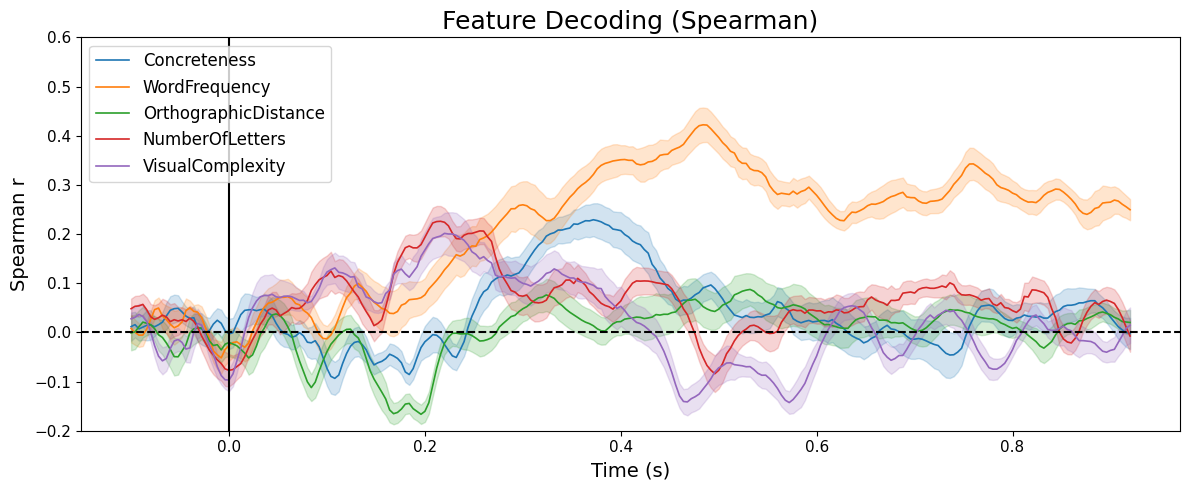

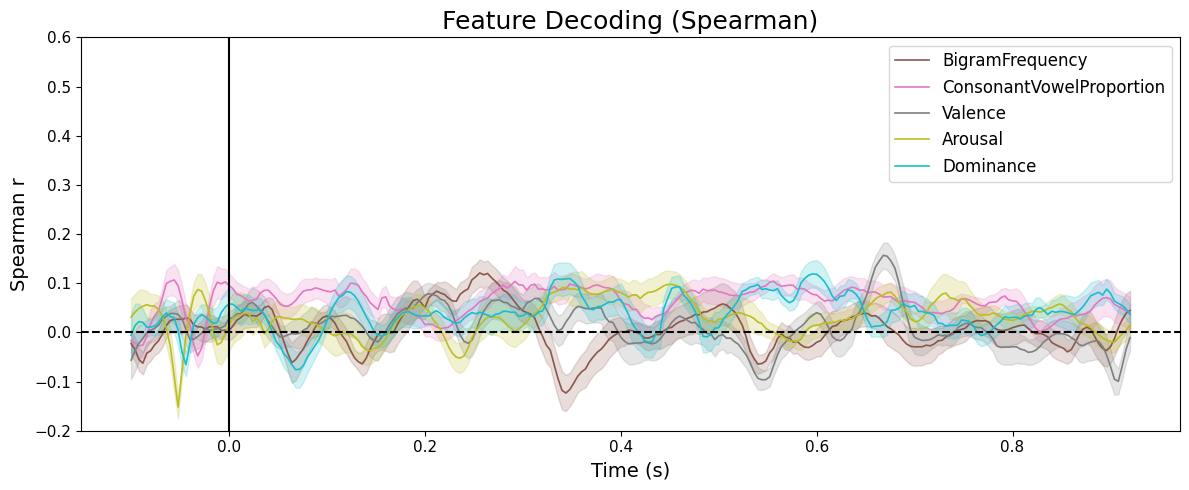

In [58]:
feature_list = list(res_features.keys())
feature_colors = plt.cm.tab10(np.linspace(0, 1, 10))
for i, (group, title) in enumerate([
    (feature_list[:5], "Feature Decoding (Spearman)"),
    (feature_list[5:], "Feature Decoding (Spearman)"),
]):
    fig, ax = plt.subplots(figsize=(12, 5))
    for name in group:
        idx = feature_list.index(name)
        fold_scores = np.load(f"fold_scores_{name}_spearman.npy")
        mean = fold_scores.mean(axis=0)
        se = fold_scores.std(axis=0) / np.sqrt(10)
        color = feature_colors[idx]
        ax.plot(times, mean, label=name, color=color, linewidth=1.2)
        ax.fill_between(times, mean - se, mean + se, alpha=0.2, color=color)
    ax.axhline(0, color="k", linestyle="--")
    ax.axvline(0.0, color="k", linestyle="-")
    ax.set_xlabel("Time (s)", fontsize=14)
    ax.set_ylabel("Spearman r", fontsize=14)
    ax.set_title(title, fontsize=18)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=12)
    ax.set_ylim(-0.2, 0.6)
    plt.tight_layout()
    plt.savefig(f"feature_decoding_part{i+1}_spearman.png", dpi=300, bbox_inches="tight")
    plt.show()

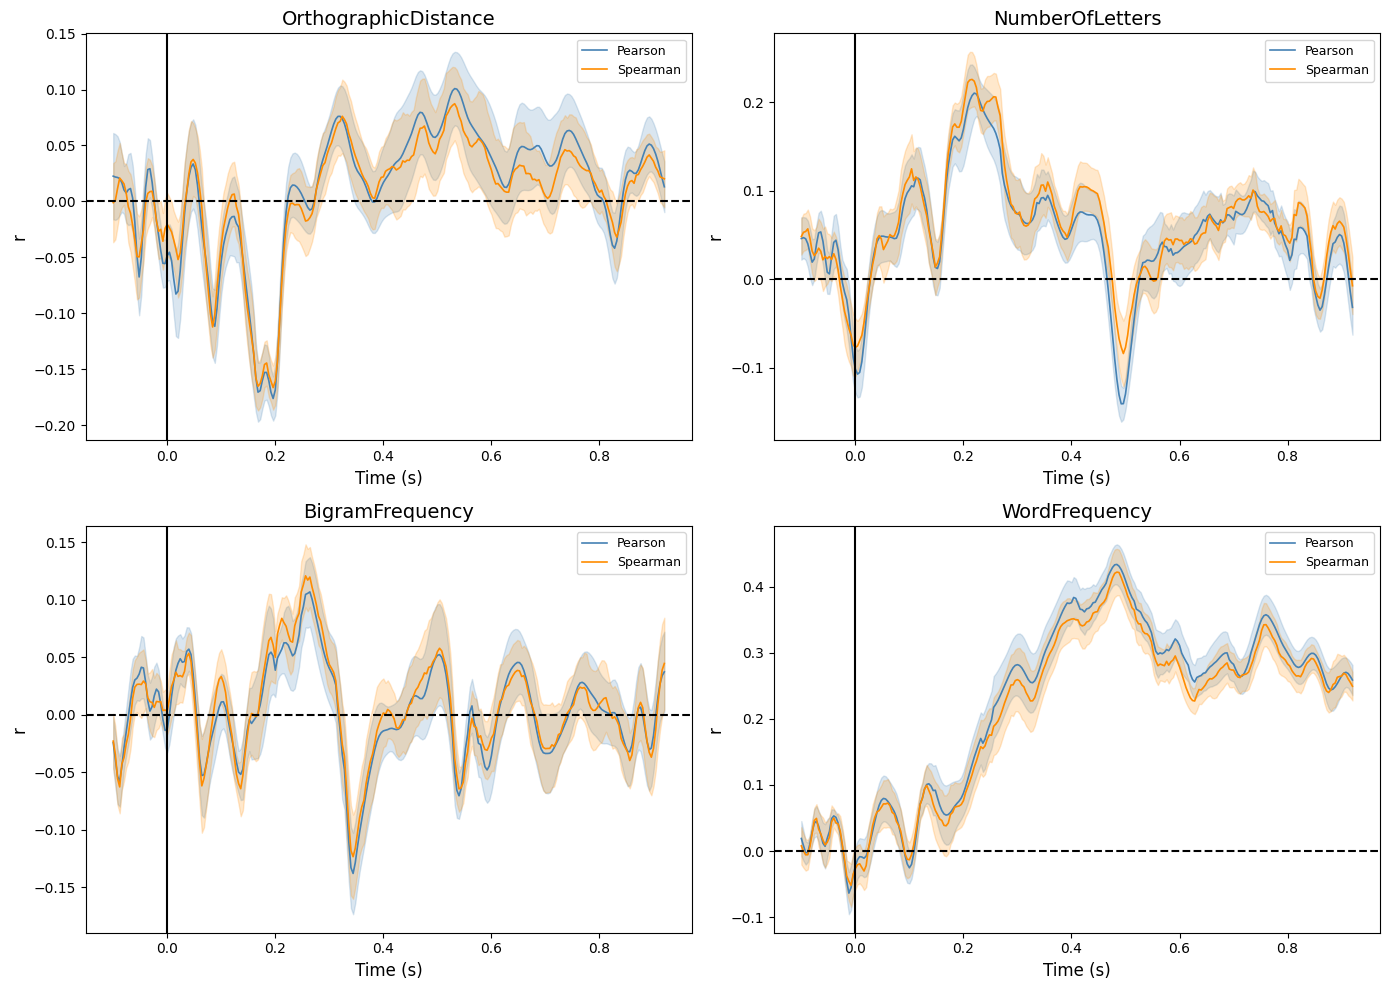

In [60]:
#Check if Spearman r makes a difference

compare_features = ["OrthographicDistance", "NumberOfLetters", "BigramFrequency", "WordFrequency"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, name in enumerate(compare_features):
    fold_scores_p = np.load(f"fold_scores_{name}.npy")            # Pearson
    fold_scores_s = np.load(f"fold_scores_{name}_spearman.npy")   # Spearman

    mean_p = fold_scores_p.mean(axis=0)
    se_p = fold_scores_p.std(axis=0) / np.sqrt(10)

    mean_s = fold_scores_s.mean(axis=0)
    se_s = fold_scores_s.std(axis=0) / np.sqrt(10)

    ax = axes[i]
    ax.plot(times, mean_p, label="Pearson", color="steelblue", linewidth=1.2)
    ax.fill_between(times, mean_p - se_p, mean_p + se_p, alpha=0.2, color="steelblue")

    ax.plot(times, mean_s, label="Spearman", color="darkorange", linewidth=1.2)
    ax.fill_between(times, mean_s - se_s, mean_s + se_s, alpha=0.2, color="darkorange")

    ax.axhline(0, color="k", linestyle="--")
    ax.axvline(0.0, color="k", linestyle="-")
    ax.set_xlabel("Time (s)", fontsize=12)
    ax.set_ylabel("r", fontsize=12)
    ax.set_title(name, fontsize=14)
    ax.tick_params(labelsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("feature_decoding_pearson_vs_spearman_skewed.png", dpi=300, bbox_inches="tight")
plt.show()

In [62]:
#check correlation peaks

for name in res_features:
    scores = np.load(f"mean_scores_{name}.npy")
    peak_r = scores.max()
    peak_t = times[scores.argmax()]
    trough_r = scores.min()
    trough_t = times[scores.argmin()]
    print(f"{name:30s}  peak: r={peak_r:.3f} at {peak_t:.3f}s  |  trough: r={trough_r:.3f} at {trough_t:.3f}s")
    

Concreteness                    peak: r=0.220 at 0.368s  |  trough: r=-0.105 at 0.108s
WordFrequency                   peak: r=0.434 at 0.484s  |  trough: r=-0.064 at -0.012s
OrthographicDistance            peak: r=0.101 at 0.532s  |  trough: r=-0.176 at 0.196s
NumberOfLetters                 peak: r=0.210 at 0.220s  |  trough: r=-0.141 at 0.492s
VisualComplexity                peak: r=0.221 at 0.224s  |  trough: r=-0.154 at 0.468s
BigramFrequency                 peak: r=0.107 at 0.264s  |  trough: r=-0.138 at 0.344s
ConsonantVowelProportion        peak: r=0.119 at 0.552s  |  trough: r=-0.056 at -0.032s
Valence                         peak: r=0.150 at 0.668s  |  trough: r=-0.097 at 0.544s
Arousal                         peak: r=0.096 at 0.452s  |  trough: r=-0.163 at -0.052s
Dominance                       peak: r=0.128 at 0.596s  |  trough: r=-0.075 at -0.044s


In [63]:
#─── FastText Decoding  ──────────────────────────────────────────────────────
# _, fold_scores_ft, fold_scores_dim_ft, mean_scores_ft = decode_vectors(X, ft_vectors, cv)
# np.save("fold_scores_ft.npy", fold_scores_ft)
# np.save("fold_scores_dim_ft.npy", fold_scores_dim_ft)
# np.save("mean_scores_ft.npy", mean_scores_ft)



In [64]:
#─── GPT-2 Layerwise Decoding  ──────────────────────────────────────────────────────
# for layer_idx in range(n_layers):
#     print(f"Decoding GPT2 layer {layer_idx}...")
#     _, fold_scores, fold_scores_dim, mean_scores = decode_vectors(X, gpt_vectors[layer_idx], cv)
#     np.save(f"fold_scores_gpt2_layer{layer_idx}.npy", fold_scores)
#     np.save(f"fold_scores_dim_gpt2_layer{layer_idx}.npy", fold_scores_dim)
#     np.save(f"mean_scores_gpt2_layer{layer_idx}.npy", mean_scores)

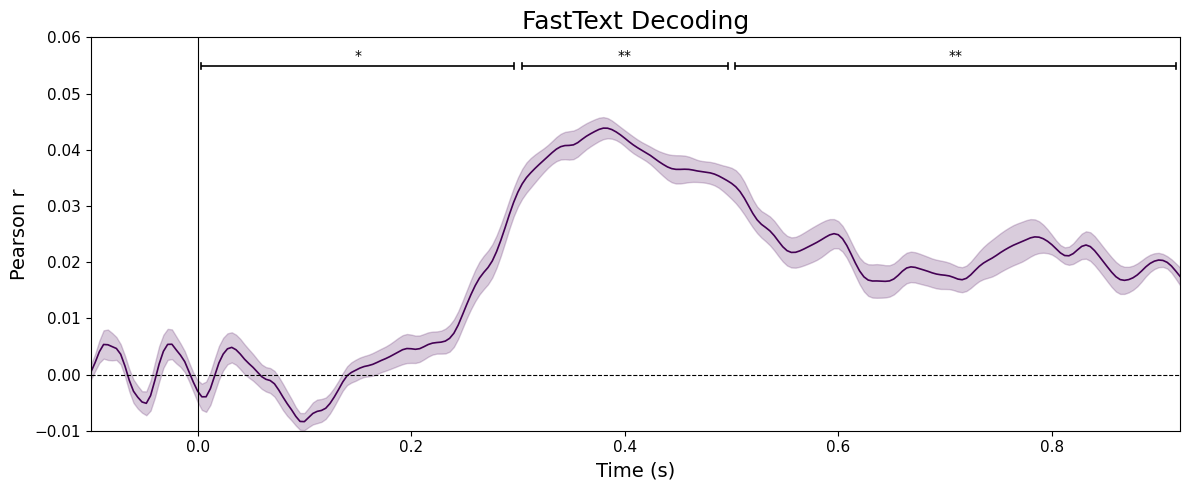

In [67]:
#─── FastText Decoding Plot ──────────────────────────────────────────────────────
fold_scores_ft = np.load("fold_scores_ft.npy")
mean_ft, se_ft = mean_and_se(fold_scores_ft)

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(times, mean_ft, color=colors[0], linewidth=1.2)
ax.fill_between(times, mean_ft - se_ft, mean_ft + se_ft, alpha=0.2, color=colors[0])

# pFDR from Table A2
add_sig_bars(ax, [
    {"t_start": 0.0,  "t_end": 0.3,  "p": 0.038, "y": 0.0549},
    {"t_start": 0.3,  "t_end": 0.5,  "p": 0.006, "y": 0.0549},
    {"t_start": 0.5,  "t_end": 0.92, "p": 0.006, "y": 0.0549},
], gap=0.0035, cap_height=0.0005)
finish_and_save(fig, ax, "decoding_ft.png", "FastText Decoding", "Pearson r", ylim=(-0.01, 0.06))

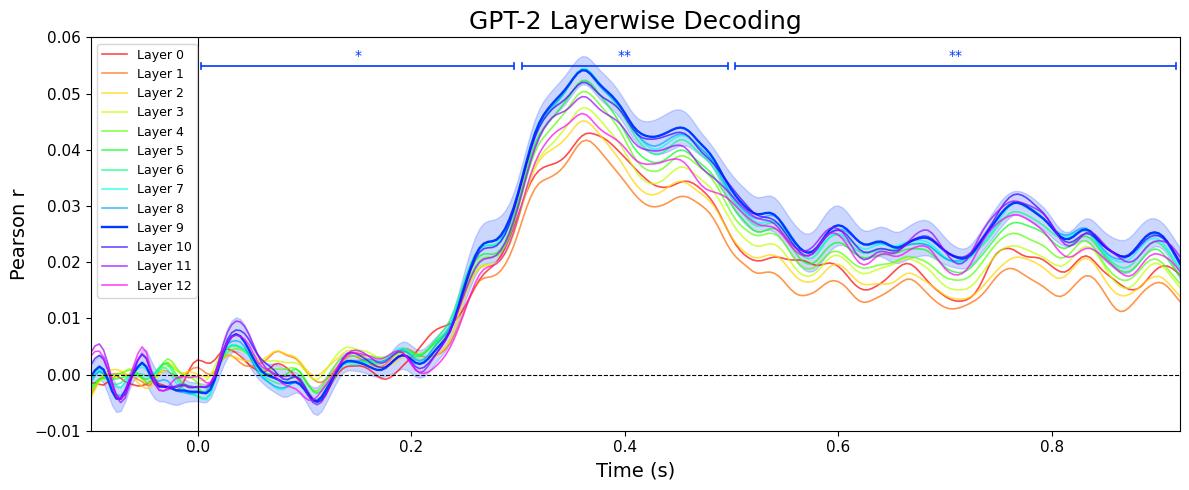

In [69]:
#─── GPT-2 Layerwise Decoding Plot ──────────────────────────────────────────────────────

mean_per_layer_baseline = np.array([np.load(f"mean_scores_gpt2_layer{l}.npy") for l in range(N_LAYERS)])
fold_scores_l9 = np.load("fold_scores_gpt2_layer9.npy")
_, se_l9 = mean_and_se(fold_scores_l9)

# pFDR from Table A3
plot_layerwise(mean_per_layer_baseline, se_l9, "GPT-2 Layerwise Decoding", "decoding_gpt2_layers.png",
               ylim=(-0.01, 0.06), sig_windows=[
    {"t_start": 0.0,  "t_end": 0.3,  "p": 0.0146, "y": 0.0549},
    {"t_start": 0.3,  "t_end": 0.5,  "p": 0.0046, "y": 0.0549},
    {"t_start": 0.5,  "t_end": 0.92, "p": 0.0046, "y": 0.0549},
])

In [70]:
#─── Layer selection: best mean decoding in N400 window → used for all GPT-2 analyses ─────────────────────────────────

n400_mask = (times >= 0.3) & (times <= 0.5)

layer_n400_means = []
for l in range(n_layers):
    fs = np.load(f"fold_scores_gpt2_layer{l}.npy")
    layer_n400_means.append(fs[:, n400_mask].mean())

for l, m in enumerate(layer_n400_means):
    print(f"Layer {l:2d}: mean r = {m:.4f}")

print(f"\nBest layer: {np.argmax(layer_n400_means)}")


Layer  0: mean r = 0.0357
Layer  1: mean r = 0.0329
Layer  2: mean r = 0.0359
Layer  3: mean r = 0.0379
Layer  4: mean r = 0.0402
Layer  5: mean r = 0.0416
Layer  6: mean r = 0.0434
Layer  7: mean r = 0.0440
Layer  8: mean r = 0.0440
Layer  9: mean r = 0.0446
Layer 10: mean r = 0.0436
Layer 11: mean r = 0.0414
Layer 12: mean r = 0.0387

Best layer: 9


In [43]:
# # GPT2 Ablation — Concreteness all Layer ──────────────────────────────────────────────────────
# for layer_idx in range(n_layers):
#     print(f"Residualizing layer {layer_idx}...")
#     res_model = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.1, 1, 10, 100, 1000]))
#     gpt_pred_by_conc = cross_val_predict(res_model, res_conc.reshape(-1, 1), gpt_vectors[layer_idx], cv=cv)
#     gpt_vectors_wo_conc = gpt_vectors[layer_idx] - gpt_pred_by_conc

#     _, fold_scores, fold_scores_dim, mean_scores = decode_vectors(X, gpt_vectors_wo_conc, cv)
#     np.save(f"fold_scores_gpt_wo_conc_layer{layer_idx}.npy", fold_scores)
#     np.save(f"fold_scores_dim_gpt_wo_conc_layer{layer_idx}.npy", fold_scores_dim)
#     np.save(f"mean_scores_gpt_wo_conc_layer{layer_idx}.npy", mean_scores)
#     print(f"  done.")Ich ver

In [44]:
##Fasttext Ablation for all features ─────────────────────────────────────────────────────────────────

# for name, res in res_features.items():
#     print(f"Ablation: {name}...")
#     res_model = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.1, 1, 10, 100, 1000]))
#     ft_pred_by_feature = cross_val_predict(res_model, res.reshape(-1, 1), ft_vectors, cv=cv)
#     ft_vectors_wo = ft_vectors - ft_pred_by_feature

#     _, fold_scores, fold_scores_dim, mean_scores = decode_vectors(X, ft_vectors_wo, cv)
#     np.save(f"fold_scores_ft_wo_{name}.npy", fold_scores)
#     np.save(f"fold_scores_dim_ft_wo_{name}.npy", fold_scores_dim)
#     np.save(f"mean_scores_ft_wo_{name}.npy", mean_scores)
#     print(f"  done.")

In [72]:
# ── time windows ───────────────────────────────────────────────────
masks = {
    "0–300ms":   (times >= 0.0) & (times <= 0.3),
    "300–500ms": (times >= 0.3) & (times <= 0.5),
    "500–920ms": (times >= 0.5) & (times <= 0.92),
}

# ── ablation ───────────────────────────────────────────────────────
ft_wo_files = {
    "Concreteness":             "fold_scores_ft_wo_Concreteness.npy",
    "WordFrequency":            "fold_scores_ft_wo_WordFrequency.npy",
    "OrthographicDistance":     "fold_scores_ft_wo_OrthographicDistance.npy",
    "NumberOfLetters":          "fold_scores_ft_wo_NumberOfLetters.npy",
    "VisualComplexity":         "fold_scores_ft_wo_VisualComplexity.npy",
    "BigramFrequency":          "fold_scores_ft_wo_BigramFrequency.npy",
    "ConsonantVowelProportion": "fold_scores_ft_wo_ConsonantVowelProportion.npy",
    "Valence":                  "fold_scores_ft_wo_Valence.npy",
    "Arousal":                  "fold_scores_ft_wo_Arousal.npy",
    "Dominance":                "fold_scores_ft_wo_Dominance.npy",
}

gpt_wo_files = {
    "Concreteness":             "fold_scores_gpt_wo_conc_layer9.npy",
    "WordFrequency":            "fold_scores_gpt_wo_WordFrequency_layer9.npy",
    "OrthographicDistance":     "fold_scores_gpt_wo_OrthographicDistance_layer9.npy",
    "NumberOfLetters":          "fold_scores_gpt_wo_NumberOfLetters_layer9.npy",
    "VisualComplexity":         "fold_scores_gpt_wo_VisualComplexity_layer9.npy",
    "BigramFrequency":          "fold_scores_gpt_wo_BigramFrequency_layer9.npy",
    "ConsonantVowelProportion": "fold_scores_gpt_wo_ConsonantVowelProportion_layer9.npy",
    "Valence":                  "fold_scores_gpt_wo_Valence_layer9.npy",
    "Arousal":                  "fold_scores_gpt_wo_Arousal_layer9.npy",
    "Dominance":                "fold_scores_gpt_wo_Dominance_layer9.npy",
}


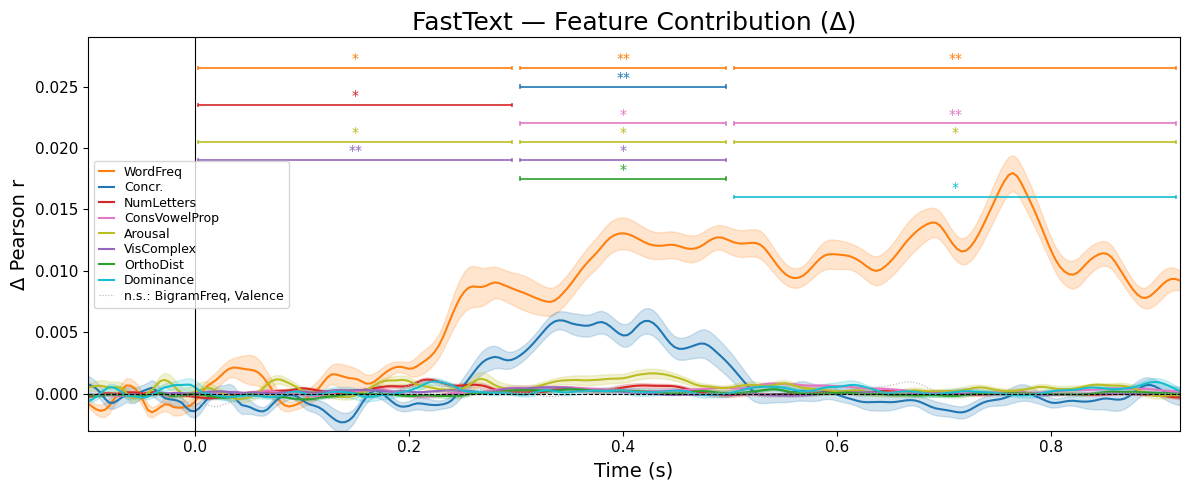

In [56]:
# pFDR from Table A4 (only significant windows)
#─ ── FastText ablation delta plot ───────────────────────────────────────────────────

sig_windows_per_feature = {
    "Concreteness":             [{"t_start": 0.3,  "t_end": 0.5,  "p": 0.006}],
    "WordFrequency":            [{"t_start": 0.0,  "t_end": 0.3,  "p": 0.010},
                                 {"t_start": 0.3,  "t_end": 0.5,  "p": 0.006},
                                 {"t_start": 0.5,  "t_end": 0.92, "p": 0.006}],
    "OrthographicDistance":     [{"t_start": 0.3,  "t_end": 0.5,  "p": 0.038}],
    "NumberOfLetters":          [{"t_start": 0.0,  "t_end": 0.3,  "p": 0.010}],
    "VisualComplexity":         [{"t_start": 0.0,  "t_end": 0.3,  "p": 0.009},
                                 {"t_start": 0.3,  "t_end": 0.5,  "p": 0.038}],
    "ConsonantVowelProportion": [{"t_start": 0.3,  "t_end": 0.5,  "p": 0.010},
                                 {"t_start": 0.5,  "t_end": 0.92, "p": 0.009}],
    "Arousal":                  [{"t_start": 0.0,  "t_end": 0.3,  "p": 0.038},
                                 {"t_start": 0.3,  "t_end": 0.5,  "p": 0.027},
                                 {"t_start": 0.5,  "t_end": 0.92, "p": 0.027}],
    "Dominance":                [{"t_start": 0.5,  "t_end": 0.92, "p": 0.047}],
}
sig_features = set(sig_windows_per_feature)
y_heights = {
    "WordFrequency":            0.0265,
    "Concreteness":             0.0250,
    "NumberOfLetters":          0.0235,
    "ConsonantVowelProportion": 0.0220,
    "Arousal":                  0.0205,
    "VisualComplexity":         0.0190,
    "OrthographicDistance":     0.0175,
    "Dominance":                0.0160,
}
legend_order = ["WordFrequency", "Concreteness", "NumberOfLetters", "ConsonantVowelProportion",
                "Arousal", "VisualComplexity", "OrthographicDistance", "Dominance"]
# short legend labels (only for this plot)
legend_labels = {
    "WordFrequency": "WordFreq", "Concreteness": "Concr.", "NumberOfLetters": "NumLetters",
    "ConsonantVowelProportion": "ConsVowelProp", "Arousal": "Arousal",
    "VisualComplexity": "VisComplex", "OrthographicDistance": "OrthoDist", "Dominance": "Dominance",
}
fold_scores_ft = np.load("fold_scores_ft.npy")
fig, ax = plt.subplots(figsize=FIGSIZE)
# significant features with SE shading
for name in legend_order:
    color = FEATURE_COLOR[name]
    fold_scores_wo = np.load(f"fold_scores_ft_wo_{name}.npy")
    mean_delta, se_delta = mean_and_se(fold_scores_ft - fold_scores_wo)
    ax.plot(times, mean_delta, label=legend_labels[name], linewidth=1.5, color=color)
    ax.fill_between(times, mean_delta - se_delta, mean_delta + se_delta, alpha=0.2, color=color)
# non-significant features (no SE)
ns_plotted = False
for name in FEATURE_NAMES:
    if name not in sig_features:
        fold_scores_wo = np.load(f"fold_scores_ft_wo_{name}.npy")
        delta = (fold_scores_ft - fold_scores_wo).mean(axis=0)
        label = "n.s.: BigramFreq, Valence" if not ns_plotted else "_nolegend_"
        ax.plot(times, delta, linewidth=0.8, color="darkgray", alpha=0.9,
                label=label, linestyle=":")
        ns_plotted = True
# significance bars
for name, windows in sig_windows_per_feature.items():
    for w in windows:
        add_sig_bars(ax, [{**w, "y": y_heights[name]}], gap=0.0035, cap_height=0.0001,
                     color=FEATURE_COLOR[name])
finish_and_save(fig, ax, "delta_ft_all_features.png", "FastText — Feature Contribution (Δ)",
                "Δ Pearson r", ylim=(-0.003, 0.029),
                legend_kwargs=dict(loc="best", fontsize=9, handlelength=1.2, labelspacing=0.2))

In [73]:
# ── FastText ablation: peak Δr per time window ───────────────────────────────────────

mean_scores_ft = np.load("mean_scores_ft.npy")
for name in legend_order:
    print(f"\n── {name} ──")
    for win_name, mask in masks.items():
        baseline = fold_scores_ft[:, mask].mean(0)  # mean over folds, keep timepoints
        wo = np.load(ft_wo_files[name])[:, mask].mean(0)
        delta = baseline - wo
        print(f"  {win_name}: max Δr = {delta.max():.4f}")


── WordFrequency ──
  0–300ms: max Δr = 0.0091
  300–500ms: max Δr = 0.0131
  500–920ms: max Δr = 0.0180

── Concreteness ──
  0–300ms: max Δr = 0.0030
  300–500ms: max Δr = 0.0060
  500–920ms: max Δr = 0.0023

── NumberOfLetters ──
  0–300ms: max Δr = 0.0012
  300–500ms: max Δr = 0.0007
  500–920ms: max Δr = 0.0003

── ConsonantVowelProportion ──
  0–300ms: max Δr = 0.0005
  300–500ms: max Δr = 0.0005
  500–920ms: max Δr = 0.0008

── Arousal ──
  0–300ms: max Δr = 0.0012
  300–500ms: max Δr = 0.0017
  500–920ms: max Δr = 0.0008

── VisualComplexity ──
  0–300ms: max Δr = 0.0004
  300–500ms: max Δr = 0.0005
  500–920ms: max Δr = 0.0001

── OrthographicDistance ──
  0–300ms: max Δr = 0.0003
  300–500ms: max Δr = 0.0004
  500–920ms: max Δr = 0.0004

── Dominance ──
  0–300ms: max Δr = 0.0010
  300–500ms: max Δr = 0.0003
  500–920ms: max Δr = 0.0010


In [ ]:
# ── GPT-2 ablation: all features × all layers ──────────────────────


# for name, res in res_features.items():
#     tag = "conc" if name == "Concreteness" else name
#     for layer_idx in range(n_layers):
#         print(f"GPT2 Ablation: {name}, Layer {layer_idx}...")
#         res_model = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.1, 1, 10, 100, 1000]))
#         gpt_pred_by_feature = cross_val_predict(res_model, res.reshape(-1, 1), gpt_vectors[layer_idx], cv=cv)
#         gpt_vectors_wo = gpt_vectors[layer_idx] - gpt_pred_by_feature
#
#         _, fold_scores, fold_scores_dim, mean_scores = decode_vectors(X, gpt_vectors_wo, cv)
#         np.save(f"fold_scores_gpt_wo_{tag}_layer{layer_idx}.npy", fold_scores)
#         np.save(f"fold_scores_dim_gpt_wo_{tag}_layer{layer_idx}.npy", fold_scores_dim)
#         np.save(f"mean_scores_gpt_wo_{tag}_layer{layer_idx}.npy", mean_scores)
#         print(f"  done.")

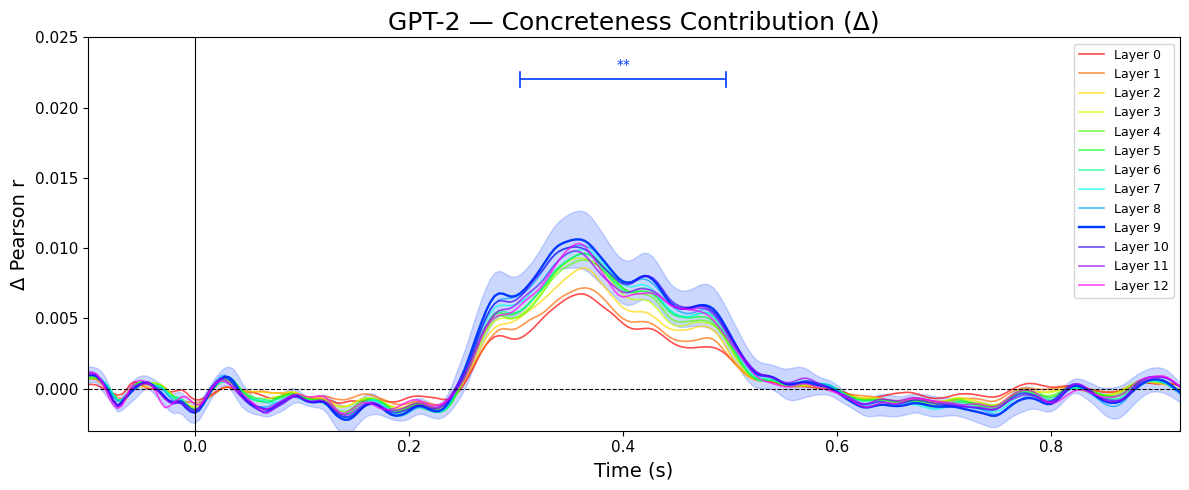

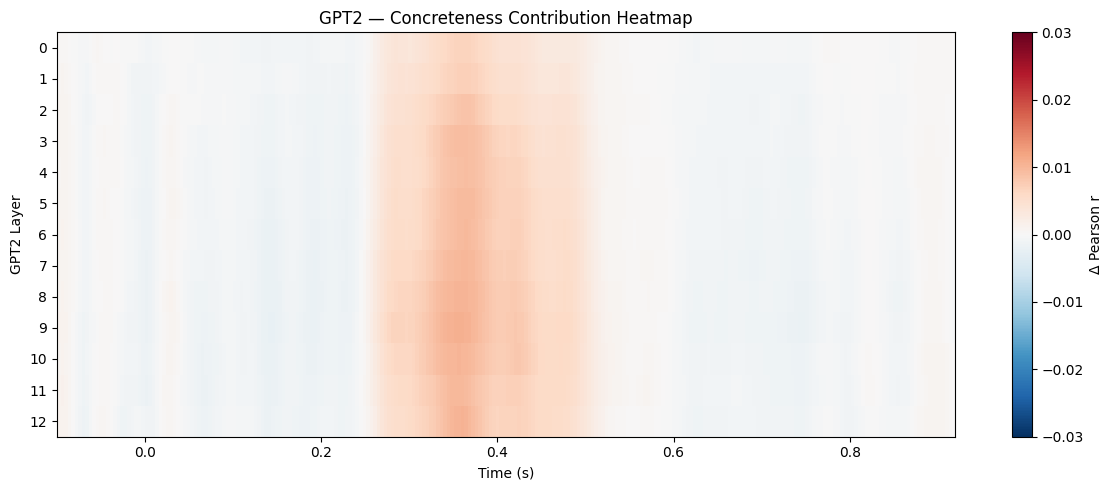

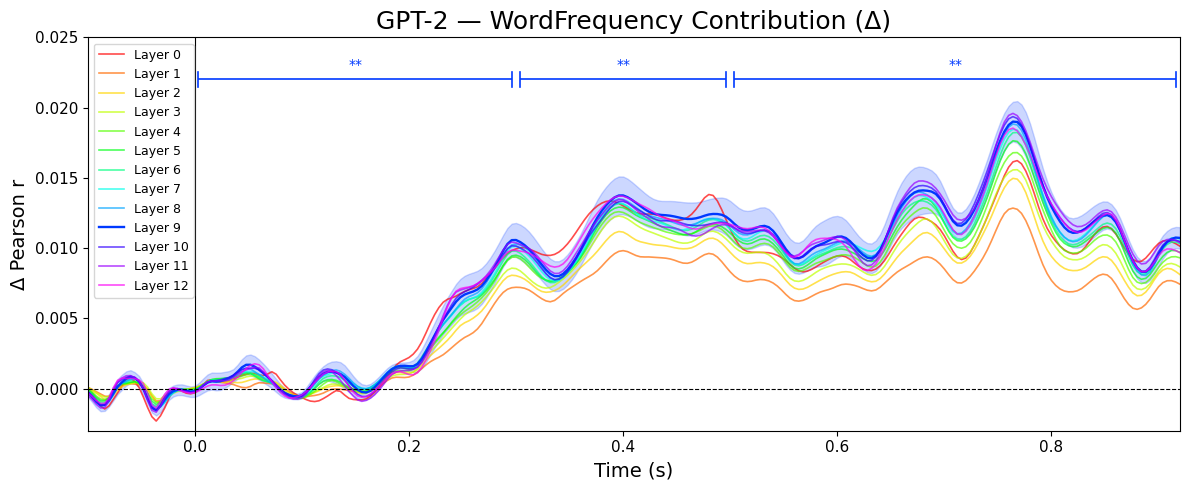

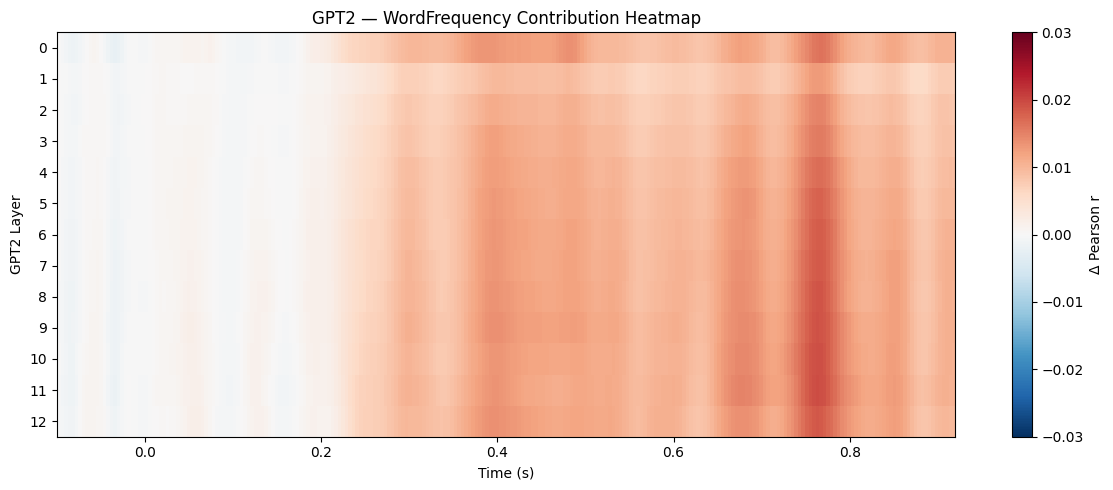

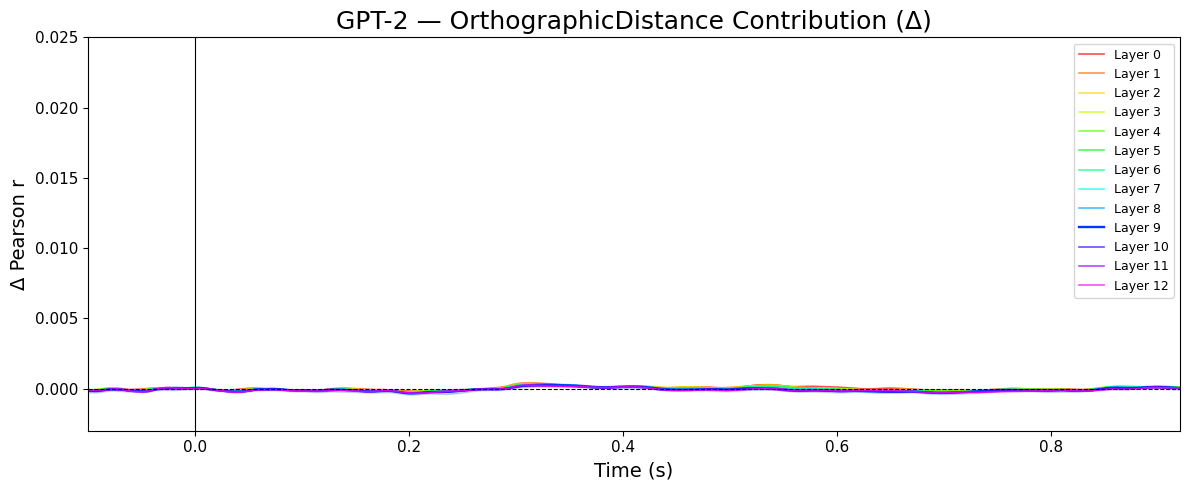

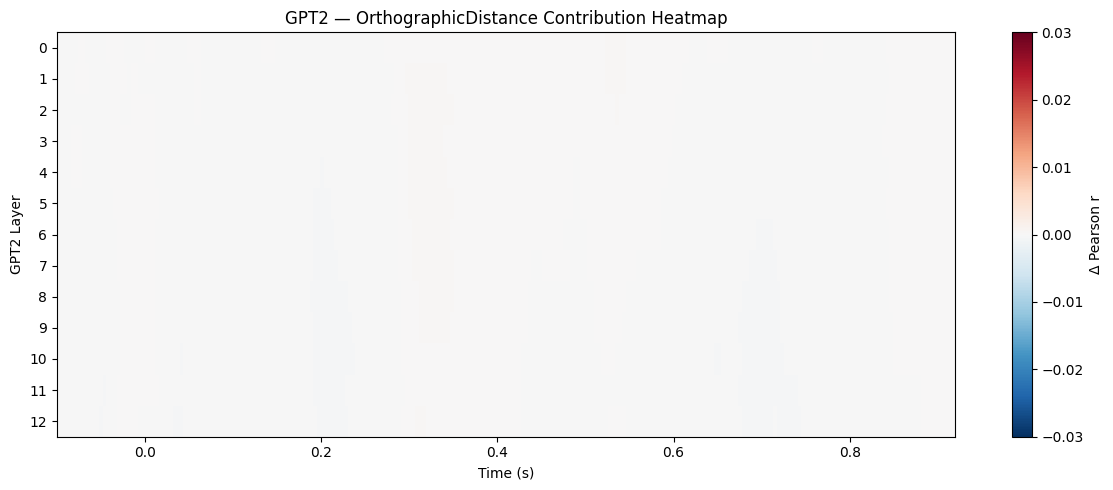

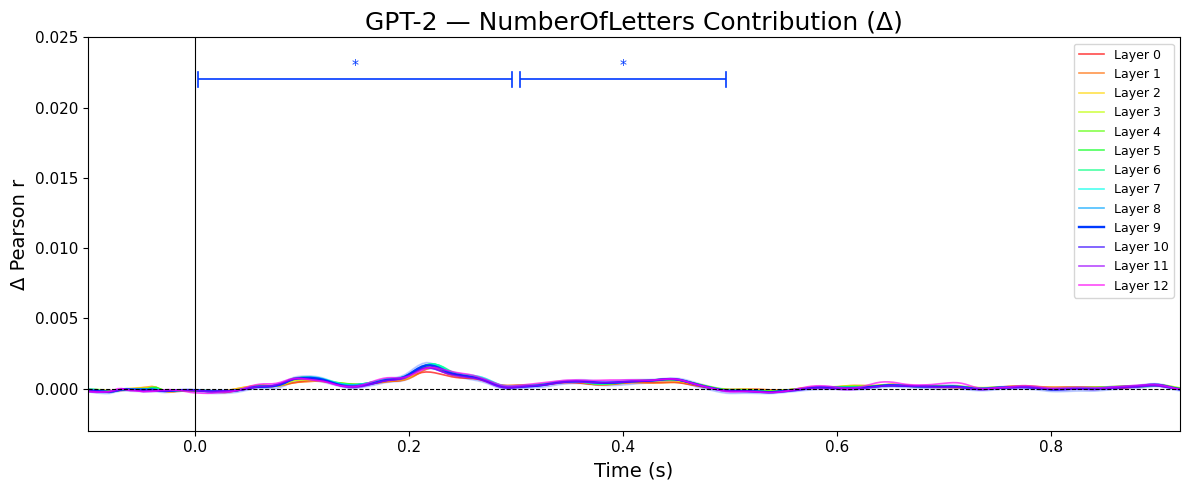

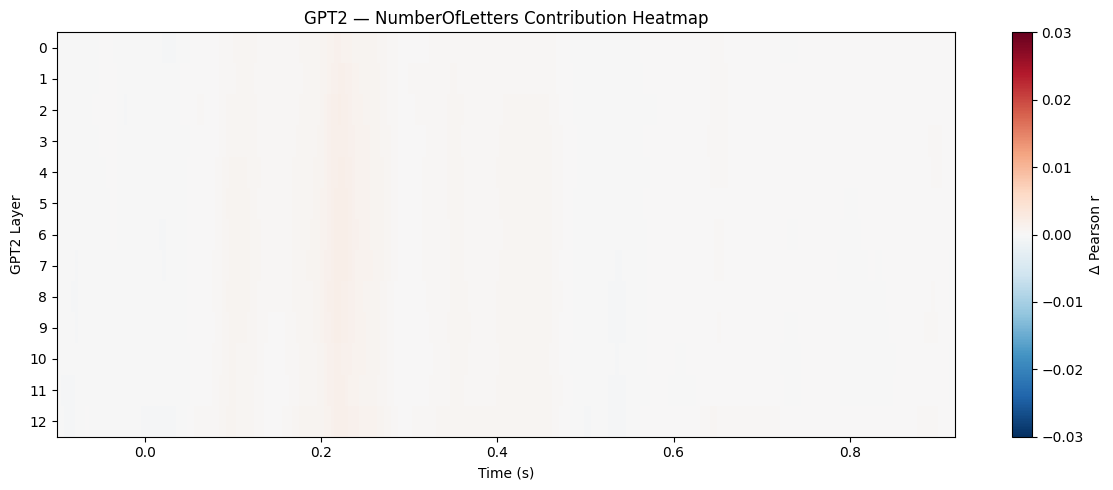

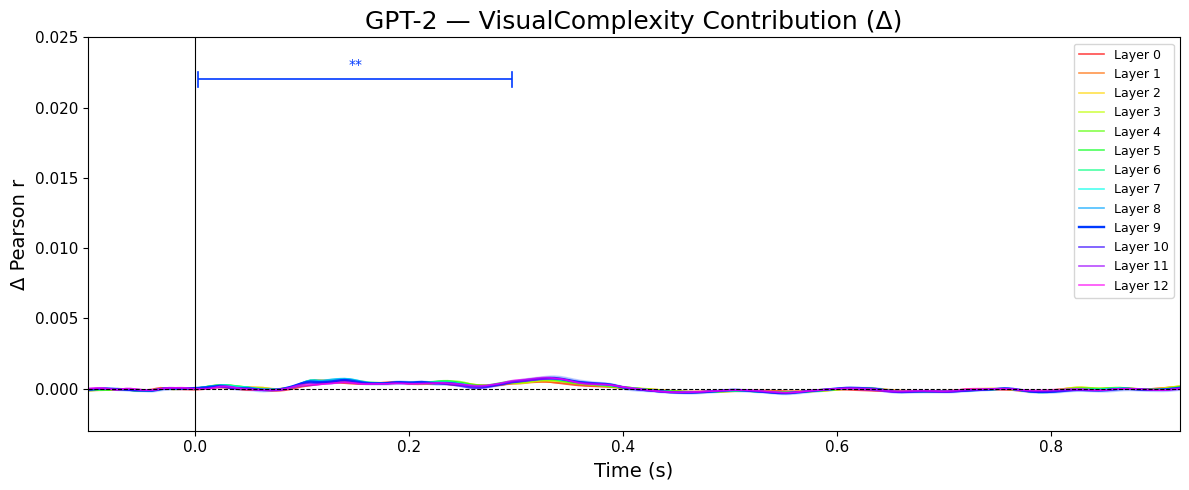

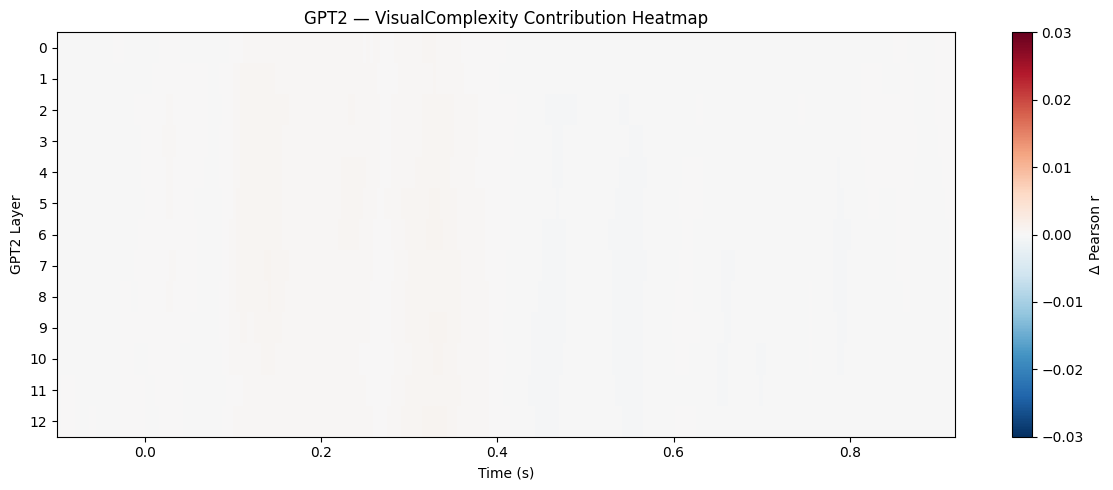

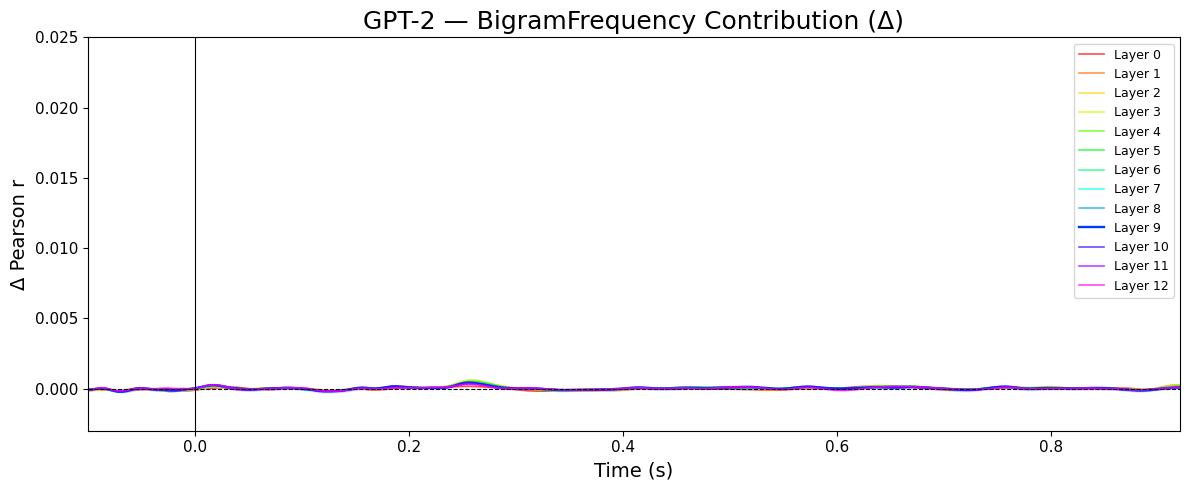

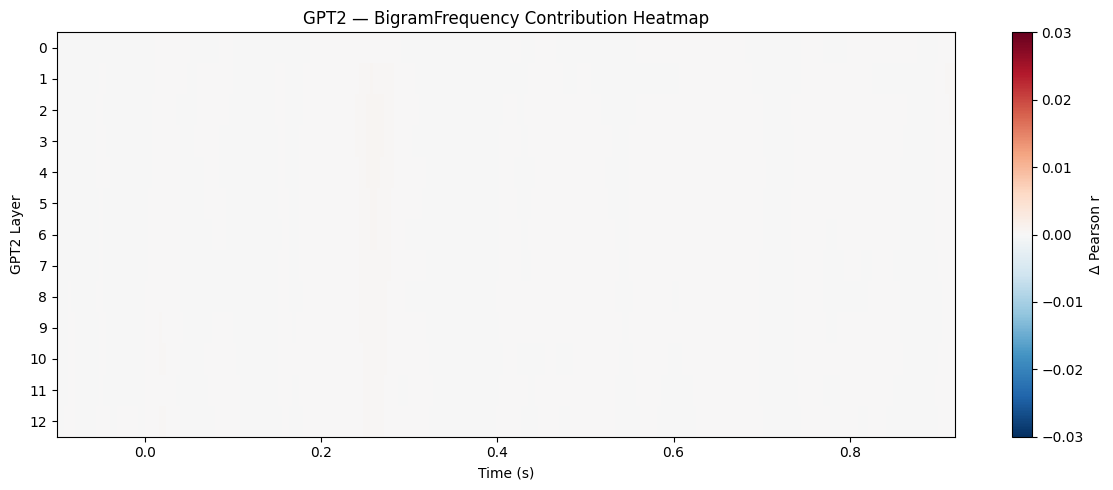

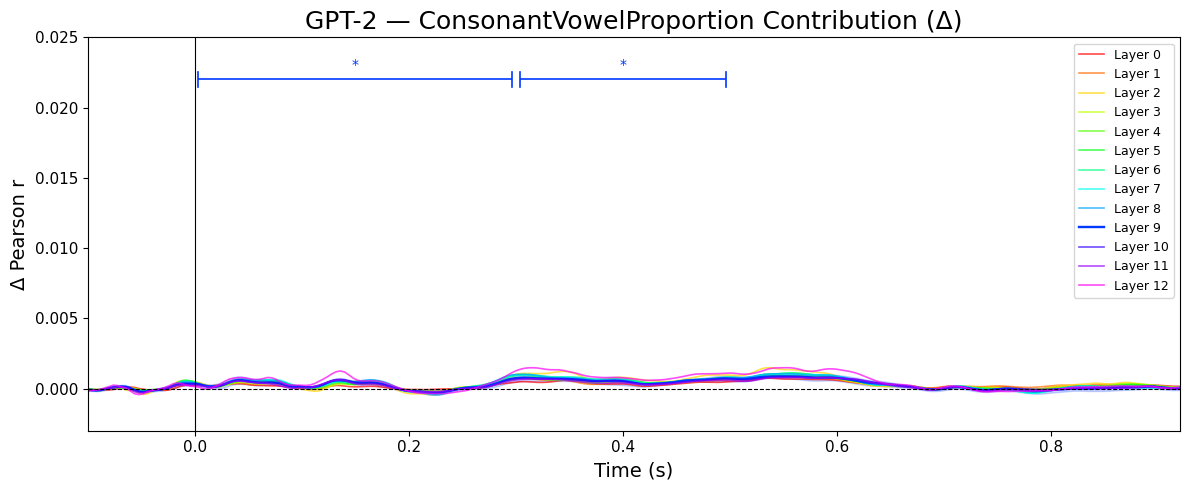

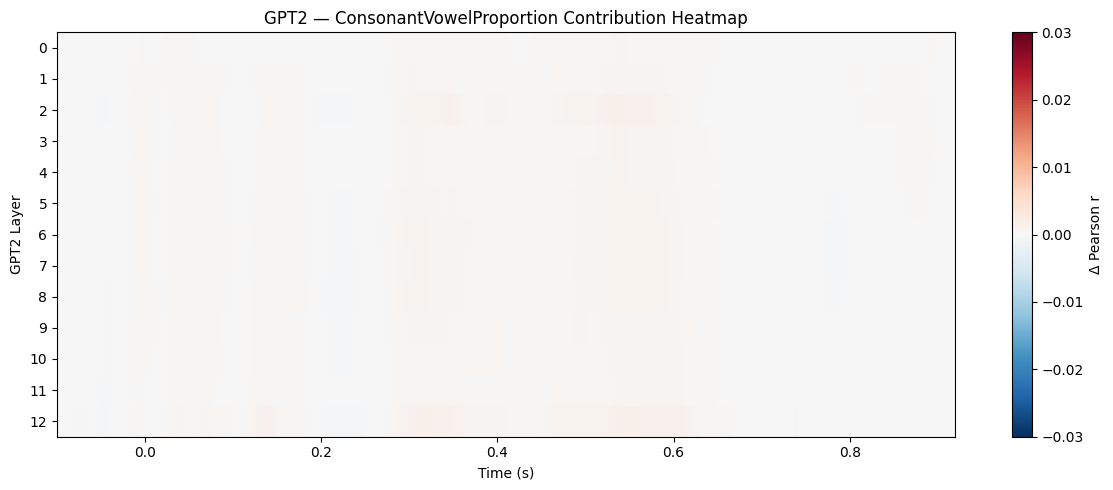

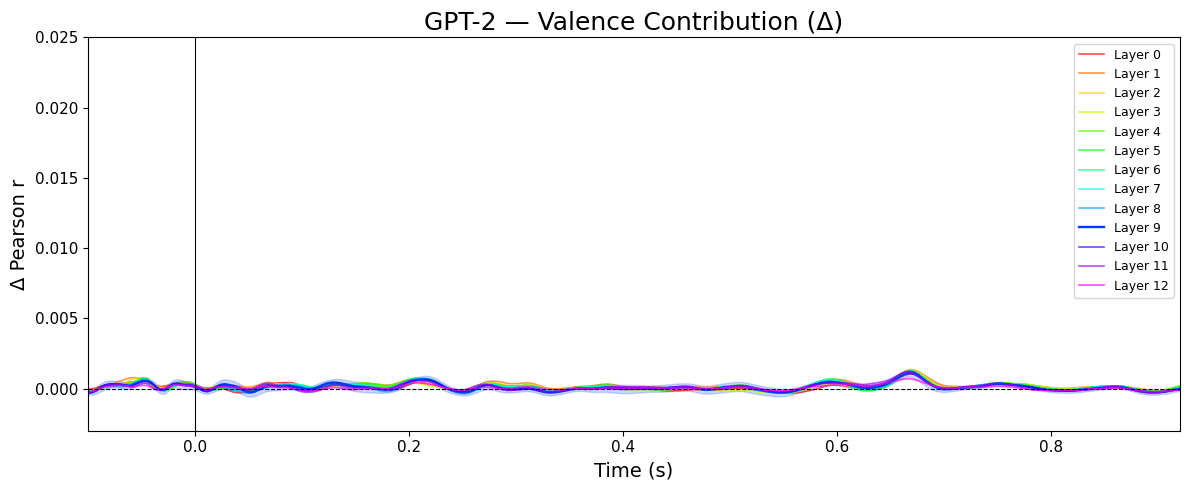

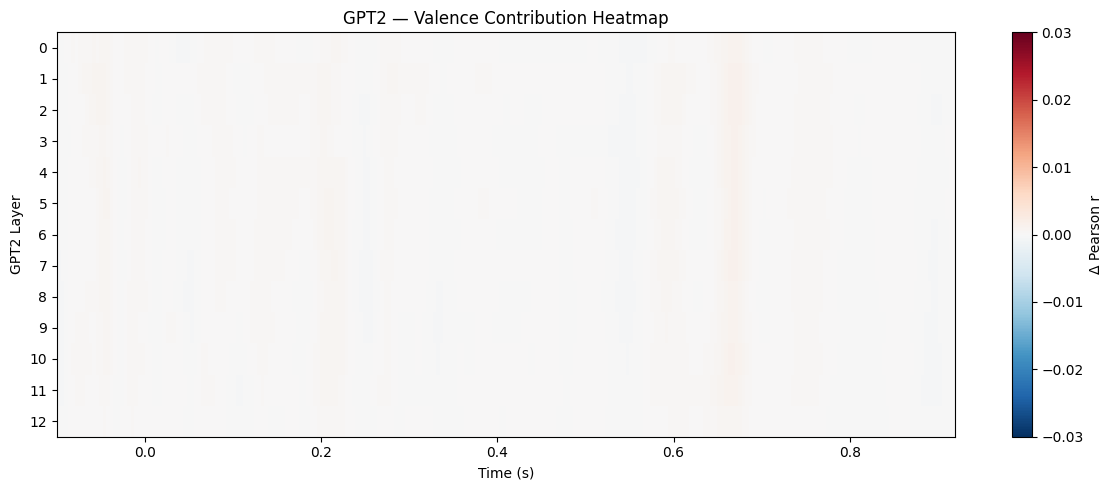

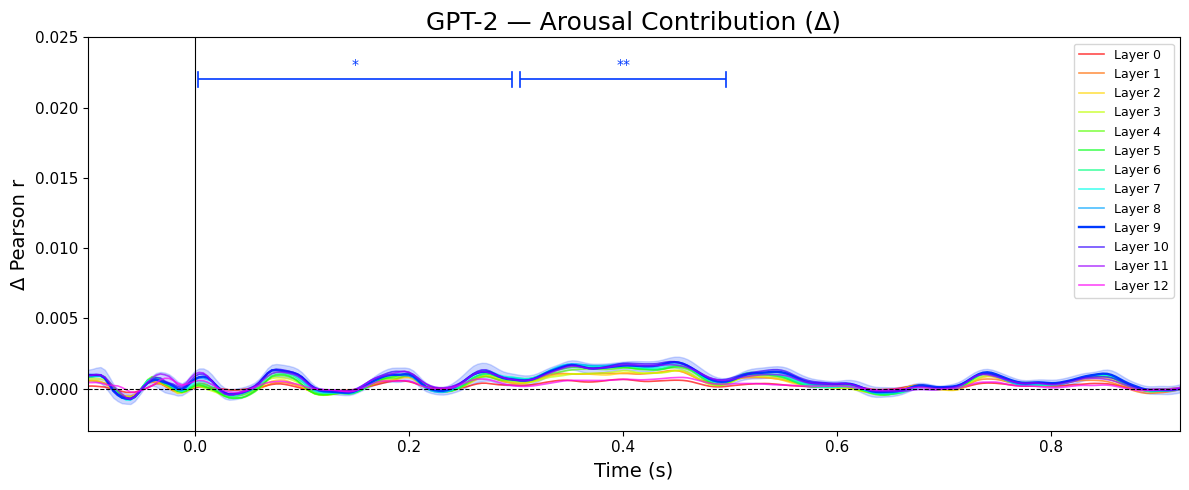

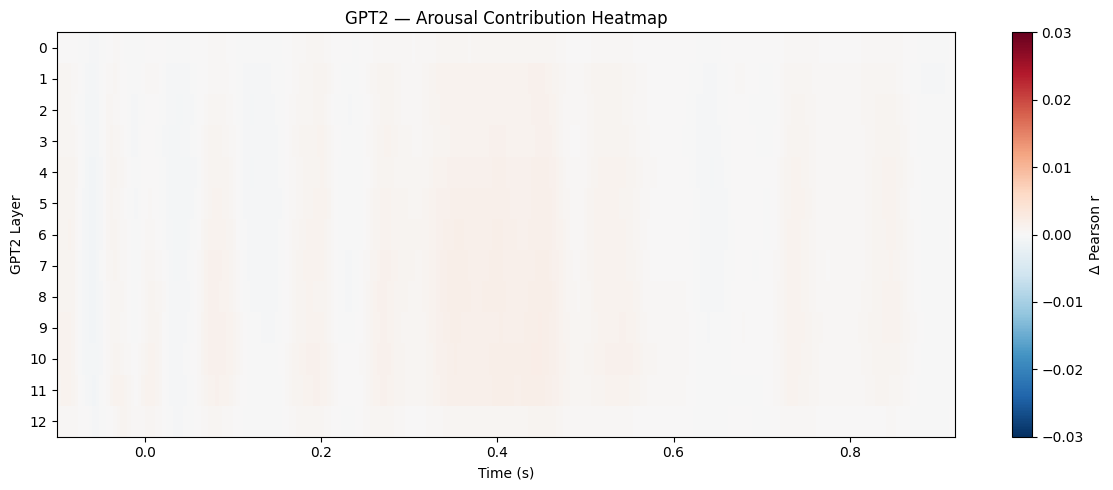

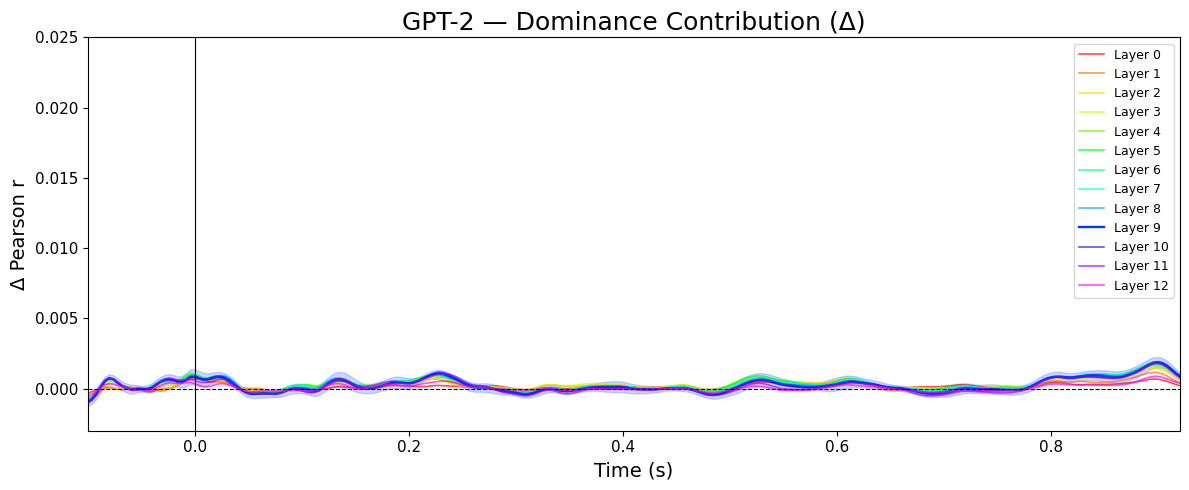

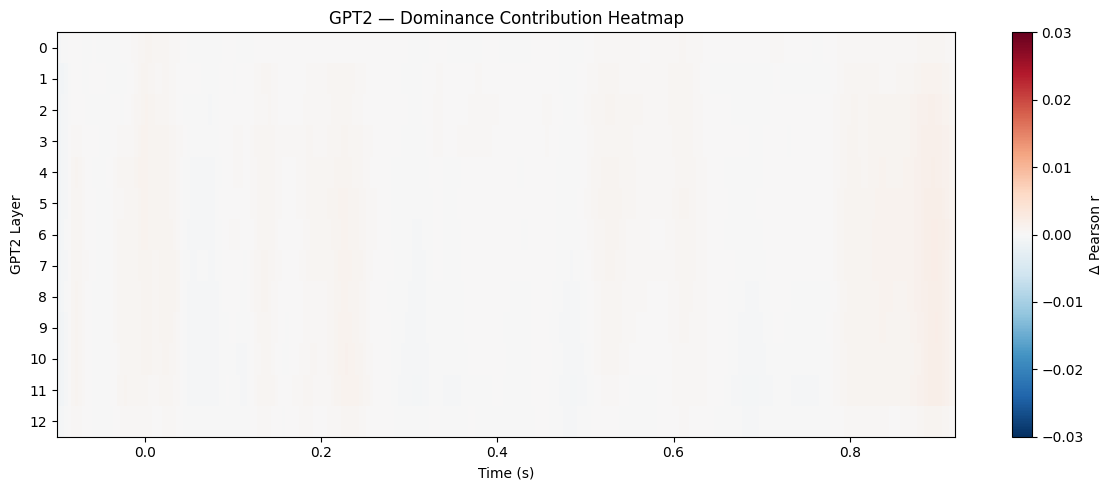

In [74]:
# GPT-2 ablation: delta plot + heatmap for every feature
# pFDR from Table A5 (empty list = no significant window)
sig_windows_gpt = {
    "Concreteness":             [{"t_start": 0.3,  "t_end": 0.5,  "p": 0.0046}],
    "WordFrequency":            [{"t_start": 0.0,  "t_end": 0.3,  "p": 0.0081},
                                 {"t_start": 0.3,  "t_end": 0.5,  "p": 0.0046},
                                 {"t_start": 0.5,  "t_end": 0.92, "p": 0.0046}],
    "OrthographicDistance":     [],
    "NumberOfLetters":          [{"t_start": 0.0,  "t_end": 0.3,  "p": 0.0146},
                                 {"t_start": 0.3,  "t_end": 0.5,  "p": 0.0188}],
    "VisualComplexity":         [{"t_start": 0.0,  "t_end": 0.3,  "p": 0.0046}],
    "BigramFrequency":          [],
    "ConsonantVowelProportion": [{"t_start": 0.0,  "t_end": 0.3,  "p": 0.0437},
                                 {"t_start": 0.3,  "t_end": 0.5,  "p": 0.0107}],
    "Valence":                  [],
    "Arousal":                  [{"t_start": 0.0,  "t_end": 0.3,  "p": 0.0248},
                                 {"t_start": 0.3,  "t_end": 0.5,  "p": 0.0046}],
    "Dominance":                [],
}
# concreteness files were saved as "..._wo_conc_layer*.npy"
file_tag = {"Concreteness": "conc"}

scores_per_layer = mean_per_layer_baseline
fold_scores_l9 = np.load("fold_scores_gpt2_layer9.npy")

for name in FEATURE_NAMES:
    tag = file_tag.get(name, name)
    scores_wo_per_layer = np.array([np.load(f"mean_scores_gpt_wo_{tag}_layer{l}.npy") for l in range(N_LAYERS)])
    delta_per_layer = scores_per_layer - scores_wo_per_layer

    # layer 9: fold-based mean so it matches the SE
    fold_scores_wo_l9 = np.load(f"fold_scores_gpt_wo_{tag}_layer9.npy")
    mean_l9, se_l9 = mean_and_se(fold_scores_l9 - fold_scores_wo_l9)
    delta_per_layer[HIGHLIGHT_LAYER] = mean_l9

    plot_layerwise(delta_per_layer, se_l9, f"GPT-2 — {name} Contribution (Δ)",
                   f"delta_gpt_{name}_all_layers.png", ylim=(-0.003, 0.025),
                   sig_windows=[{**w, "y": 0.022} for w in sig_windows_gpt[name]])
    plot_heatmap(delta_per_layer, f"GPT2 — {name} Contribution Heatmap",
                 f"heatmap_gpt_{name}_all_layers.png")

In [78]:
# ══════════════════════════════════════════════════════════════════════════════
# STATISTICS: one-sided Wilcoxon signed-rank tests on fold scores + FDR correction
#
# Every test uses the 10 CV-fold scores, averaged within a time window → 10 values.
# 4 test families, 33 tests each (3 windows × [1 baseline test + 10 features]).
# FDR (Benjamini-Hochberg) is applied separately within each family.
# Output: p_raw and p_fdr per test (Tables A2–A5)
# ══════════════════════════════════════════════════════════════════════════════

import mne
from scipy.stats import wilcoxon, PermutationMethod
import numpy as np

pm = PermutationMethod(n_resamples=9999)

masks = {
    "0–300ms":   (times >= 0.0) & (times <= 0.3),
    "300–500ms": (times >= 0.3) & (times <= 0.5),
    "500–920ms": (times >= 0.5) & (times <= 0.92),
}
win_names = list(masks.keys())

features = ["Concreteness", "WordFrequency", "OrthographicDistance", "NumberOfLetters",
            "VisualComplexity", "BigramFrequency", "ConsonantVowelProportion",
            "Valence", "Arousal", "Dominance"]

ft_wo_files  = {n: f"fold_scores_ft_wo_{n}.npy" for n in features}
gpt_wo_l9    = {n: f"fold_scores_gpt_wo_{n}_layer9.npy" for n in features}
gpt_wo_l0    = {n: f"fold_scores_gpt_wo_{n}_layer0.npy" for n in features}
ft_wo_files["Concreteness"]  = "fold_scores_ft_wo_Concreteness.npy"
gpt_wo_l9["Concreteness"]    = "fold_scores_gpt_wo_conc_layer9.npy"
gpt_wo_l0["Concreteness"]    = "fold_scores_gpt_wo_conc_layer0.npy"

fold_ft  = np.load("fold_scores_ft.npy")
fold_l0  = np.load("fold_scores_gpt2_layer0.npy")
fold_l9  = np.load("fold_scores_gpt2_layer9.npy")

def run_tests(baseline, wo_files):
    labels, pvals, stats, deltas = [], [], [], []
    # baseline vs 0
    for wn, mask in masks.items():
        s = baseline[:, mask].mean(1)
        stat, p = wilcoxon(s, alternative='greater', method=pm)
        labels.append(f"Baseline | {wn}")
        stats.append(stat); pvals.append(p); deltas.append(s.mean())
    # ablation: baseline vs without feature
    for name in features:
        wo = np.load(wo_files[name])
        for wn, mask in masks.items():
            d = baseline[:, mask].mean(1) - wo[:, mask].mean(1)
            if np.all(d == 0):
                stat, p = np.nan, 1.0
            else:
                stat, p = wilcoxon(d, alternative='greater', method=pm)
            labels.append(f"{name} | {wn}")
            stats.append(stat); pvals.append(p); deltas.append(d.mean())
    return labels, np.array(stats), np.array(pvals), np.array(deltas)

# ── FastText family (33 tests) ───────────────────────────────────────────────
labels_ft, stats_ft, pvals_ft, deltas_ft = run_tests(fold_ft, ft_wo_files)
reject_ft, pvals_fdr_ft = mne.stats.fdr_correction(pvals_ft, alpha=0.05)

print("=== FastText (FDR-corrected) ===")
for lab, d, s, p, pc, r in zip(labels_ft, deltas_ft, stats_ft, pvals_ft, pvals_fdr_ft, reject_ft):
    sig = "✓" if r else ""
    print(f"  {lab:45s}  Δr={d:.4f}  stat={s:.0f}  p_raw={p:.4f}  p_fdr={pc:.4f}  {sig}")

# ── GPT2 Layer 9 family (33 tests) ──────────────────────────────────────────
labels_gpt, stats_gpt, pvals_gpt, deltas_gpt = run_tests(fold_l9, gpt_wo_l9)
reject_gpt, pvals_fdr_gpt = mne.stats.fdr_correction(pvals_gpt, alpha=0.05)

print("\n=== GPT2 Layer 9 (FDR-corrected) ===")
for lab, d, s, p, pc, r in zip(labels_gpt, deltas_gpt, stats_gpt, pvals_gpt, pvals_fdr_gpt, reject_gpt):
    sig = "✓" if r else ""
    print(f"  {lab:45s}  Δr={d:.4f}  stat={s:.0f}  p_raw={p:.4f}  p_fdr={pc:.4f}  {sig}")

# ── L9 vs FT family (33 tests) ───────────────────────────────────────────────
labels_l9ft, stats_l9ft, pvals_l9ft, deltas_l9ft = [], [], [], []

for wn, mask in masks.items():
    d = fold_l9[:, mask].mean(1) - fold_ft[:, mask].mean(1)
    stat, p = wilcoxon(d, alternative='greater', method=pm)
    labels_l9ft.append(f"L9 vs FT baseline | {wn}")
    stats_l9ft.append(stat); pvals_l9ft.append(p); deltas_l9ft.append(d.mean())

for name in features:
    ft_wo  = np.load(ft_wo_files[name])
    gpt_wo = np.load(gpt_wo_l9[name])
    for wn, mask in masks.items():
        d_ft = fold_ft[:,  mask].mean(1) - ft_wo[:, mask].mean(1)
        d_l9 = fold_l9[:, mask].mean(1) - gpt_wo[:, mask].mean(1)
        diff = d_l9 - d_ft
        stat, p = (np.nan, 1.0) if np.all(diff == 0) else wilcoxon(diff, alternative='greater', method=pm)
        labels_l9ft.append(f"L9 vs FT delta {name} | {wn}")
        stats_l9ft.append(stat); pvals_l9ft.append(p); deltas_l9ft.append(diff.mean())

reject_l9ft, pvals_fdr_l9ft = mne.stats.fdr_correction(np.array(pvals_l9ft), alpha=0.05)

print("\n=== L9 vs FT (FDR-corrected) ===")
for lab, d, s, p, pc, r in zip(labels_l9ft, deltas_l9ft, stats_l9ft, pvals_l9ft, pvals_fdr_l9ft, reject_l9ft):
    sig = "✓" if r else ""
    print(f"  {lab:50s}  Δr={d:.4f}  stat={s:.0f}  p_raw={p:.4f}  p_fdr={pc:.4f}  {sig}")

# ── L0 vs FT family (33 tests) ───────────────────────────────────────────────
labels_l0ft, stats_l0ft, pvals_l0ft, deltas_l0ft = [], [], [], []

for wn, mask in masks.items():
    d = fold_l0[:, mask].mean(1) - fold_ft[:, mask].mean(1)
    stat, p = wilcoxon(d, alternative='greater', method=pm)
    labels_l0ft.append(f"L0 vs FT baseline | {wn}")
    stats_l0ft.append(stat); pvals_l0ft.append(p); deltas_l0ft.append(d.mean())

for name in features:
    ft_wo  = np.load(ft_wo_files[name])
    gpt_wo = np.load(gpt_wo_l0[name])
    for wn, mask in masks.items():
        d_ft = fold_ft[:,  mask].mean(1) - ft_wo[:, mask].mean(1)
        d_l0 = fold_l0[:, mask].mean(1) - gpt_wo[:, mask].mean(1)
        diff = d_l0 - d_ft
        stat, p = (np.nan, 1.0) if np.all(diff == 0) else wilcoxon(diff, alternative='greater', method=pm)
        labels_l0ft.append(f"L0 vs FT delta {name} | {wn}")
        stats_l0ft.append(stat); pvals_l0ft.append(p); deltas_l0ft.append(diff.mean())

reject_l0ft, pvals_fdr_l0ft = mne.stats.fdr_correction(np.array(pvals_l0ft), alpha=0.05)

print("\n=== L0 vs FT (FDR-corrected) ===")
for lab, d, s, p, pc, r in zip(labels_l0ft, deltas_l0ft, stats_l0ft, pvals_l0ft, pvals_fdr_l0ft, reject_l0ft):
    sig = "✓" if r else ""
    print(f"  {lab:50s}  Δr={d:.4f}  stat={s:.0f}  p_raw={p:.4f}  p_fdr={pc:.4f}  {sig}")

=== FastText (FDR-corrected) ===
  Baseline | 0–300ms                             Δr=0.0042  stat=48  p_raw=0.0186  p_fdr=0.0383  ✓
  Baseline | 300–500ms                           Δr=0.0387  stat=55  p_raw=0.0010  p_fdr=0.0064  ✓
  Baseline | 500–920ms                           Δr=0.0213  stat=55  p_raw=0.0010  p_fdr=0.0064  ✓
  Concreteness | 0–300ms                         Δr=-0.0002  stat=15  p_raw=0.9033  p_fdr=0.9315  
  Concreteness | 300–500ms                       Δr=0.0047  stat=55  p_raw=0.0010  p_fdr=0.0064  ✓
  Concreteness | 500–920ms                       Δr=-0.0003  stat=16  p_raw=0.8838  p_fdr=0.9315  
  WordFrequency | 0–300ms                        Δr=0.0028  stat=53  p_raw=0.0029  p_fdr=0.0097  ✓
  WordFrequency | 300–500ms                      Δr=0.0110  stat=55  p_raw=0.0010  p_fdr=0.0064  ✓
  WordFrequency | 500–920ms                      Δr=0.0116  stat=55  p_raw=0.0010  p_fdr=0.0064  ✓
  OrthographicDistance | 0–300ms                 Δr=-0.0001  stat=6  p_raw=0